In [1]:
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except Exception:
    display = print


sns.set_theme(style="whitegrid", context="talk")


def resolve_workspace_root():
    current = Path.cwd().resolve()
    candidates = [current, current.parent]
    for candidate in candidates:
        if (candidate / "outputs").exists() and (candidate / "New_files").exists():
            return candidate
    return current


def resolve_results_root(workspace_root: Path) -> Path:
    candidates = [
        workspace_root / "outputs" / "Run_old_prompt",
        workspace_root / "outputs" / "Run_new_prompt",
        workspace_root / "outputs",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return workspace_root / "outputs"


WORKSPACE_ROOT = resolve_workspace_root()
RESULTS_ROOT = resolve_results_root(WORKSPACE_ROOT)

# Backwards-compat name used by later cells
SNELLIUS_ROOT = RESULTS_ROOT

DEFAULT_SELECTED_RUNS = ["run_1", "run_2", "run_3"]
DEFAULT_SELECTED_MODELS = None  # LLM models to include (None = all)

GNN_MODEL_ORDER = ["GCN", "GAT", "GIN", "GraphSAGE"]

COMPARISONS = {
    "Ground truth to GNN": ("target_class", "gnn_pred"),
    "Ground truth to LLM": ("target_class", "llm_pred_parsed"),
    "LLM relative to GNN": ("gnn_pred", "llm_pred_parsed"),
}
METRIC_ORDER = [
    "accuracy",
    "mean_accuracy",
    "precision",
    "recall",
    "f1",
    "specificity",
    "mcc",
    "coverage",
]
DISPLAY_NAMES = {
    "accuracy": "Accuracy",
    "mean_accuracy": "Mean accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
    "specificity": "Specificity",
    "mcc": "MCC",
    "coverage": "Coverage",
}


In [2]:
def parse_binary_label(value):
    if value is None:
        return None
    if isinstance(value, (bool, np.bool_)):
        return int(value)
    if isinstance(value, (int, np.integer)):
        value = int(value)
        return value if value in (0, 1) else None
    if isinstance(value, (float, np.floating)):
        if float(value).is_integer():
            value = int(value)
            return value if value in (0, 1) else None
        return None

    text = str(value).strip()
    if not text or text.lower() == "unknown":
        return None

    match = re.search(r"predicted\s+class\s+is\s+([01])\b", text, flags=re.IGNORECASE)
    if match:
        return int(match.group(1))

    if text in {"0", "1"}:
        return int(text)

    if re.fullmatch(r"[01](?:\.0+)?", text):
        return int(float(text))

    return None


def normalize_llm_name(value):
    if value is None:
        return None
    text = str(value).strip()
    if not text:
        return None
    if "/" in text:
        text = text.split("/")[-1]
    return text


def list_run_dirs(results_root):
    run_dirs = []
    if results_root is None:
        return run_dirs

    results_root = Path(results_root)
    if not results_root.exists():
        return run_dirs

    for raw_path in sorted(results_root.rglob("results_raw.json")):
        run_dir = raw_path.parent
        if run_dir.is_dir() and run_dir.name.startswith("run_"):
            run_dirs.append(run_dir)

    return run_dirs


def load_run_results(run_dir):
    run_dir = Path(run_dir)
    raw_path = run_dir / "results_raw.json"
    if not raw_path.exists():
        return pd.DataFrame()

    records = pd.read_json(raw_path)
    records = records.copy()
    records["run"] = run_dir.name

    # LLM model name
    if "llm" in records.columns:
        records["llm_name_full"] = records["llm"].astype(str)
        records["model_name"] = records["llm"].map(normalize_llm_name)
    else:
        records["llm_name_full"] = str(run_dir.parent.name)
        records["model_name"] = str(run_dir.parent.name)

    # GNN model name (as in the pipeline)
    if "model" in records.columns:
        records["gnn_model"] = records["model"].astype(str)
    else:
        parent_name = str(run_dir.parent.name)
        records["gnn_model"] = parent_name if parent_name in GNN_MODEL_ORDER else None

    records["llm_pred_parsed"] = records["llm_pred"].map(parse_binary_label)
    records["target_class"] = records["target_class"].map(parse_binary_label)
    records["gnn_pred"] = records["gnn_pred"].map(parse_binary_label)
    return records


def load_selected_runs(results_root, selected_runs=None, selected_models=None, selected_gnn_models=None):
    run_dirs = list_run_dirs(results_root)
    if selected_runs is not None:
        selected_runs_set = set(selected_runs)
        run_dirs = [run_dir for run_dir in run_dirs if run_dir.name in selected_runs_set]

    frames = [load_run_results(run_dir) for run_dir in run_dirs]
    frames = [frame for frame in frames if not frame.empty]
    if not frames:
        return pd.DataFrame()

    combined = pd.concat(frames, ignore_index=True)

    if selected_models is not None:
        combined = combined[combined["model_name"].isin(list(selected_models))]

    if selected_gnn_models is not None and "gnn_model" in combined.columns:
        combined = combined[combined["gnn_model"].isin(list(selected_gnn_models))]

    model_categories = sorted(combined["model_name"].dropna().unique())
    combined["model_name"] = pd.Categorical(
        combined["model_name"],
        categories=model_categories,
        ordered=True,
    )

    if selected_runs is None:
        run_categories = sorted(combined["run"].dropna().unique())
    else:
        run_categories = list(selected_runs)
    combined["run"] = pd.Categorical(
        combined["run"],
        categories=run_categories,
        ordered=True,
    )

    if "gnn_model" in combined.columns:
        present = [m for m in GNN_MODEL_ORDER if m in set(combined["gnn_model"].dropna().unique())]
        remaining = sorted([m for m in combined["gnn_model"].dropna().unique() if m not in set(present)])
        gnn_categories = present + remaining
        combined["gnn_model"] = pd.Categorical(
            combined["gnn_model"],
            categories=gnn_categories,
            ordered=True,
        )

    return combined


## Helpers

In [3]:
def confusion_counts(y_true, y_pred):
    tp = tn = fp = fn = 0
    valid = 0
    for truth, pred in zip(y_true, y_pred):
        if truth not in (0, 1) or pred not in (0, 1):
            continue
        valid += 1
        if truth == 1 and pred == 1:
            tp += 1
        elif truth == 0 and pred == 0:
            tn += 1
        elif truth == 0 and pred == 1:
            fp += 1
        elif truth == 1 and pred == 0:
            fn += 1
    return tp, tn, fp, fn, valid


def safe_divide(numerator, denominator):
    if denominator == 0:
        return np.nan
    return numerator / denominator


def compute_binary_metrics(y_true, y_pred, total_count=None):
    tp, tn, fp, fn, valid_count = confusion_counts(y_true, y_pred)
    if total_count is None:
        total_count = len(y_true)

    accuracy = safe_divide(tp + tn, valid_count)
    precision = safe_divide(tp, tp + fp)
    recall = safe_divide(tp, tp + fn)
    specificity = safe_divide(tn, tn + fp)
    if np.isnan(precision) or np.isnan(recall) or (precision + recall) == 0:
        f1 = np.nan
    else:
        f1 = 2 * precision * recall / (precision + recall)
    if np.isnan(recall) or np.isnan(specificity):
        mean_accuracy = np.nan
    else:
        mean_accuracy = (recall + specificity) / 2

    denominator = math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    if denominator == 0:
        mcc = np.nan
    else:
        mcc = ((tp * tn) - (fp * fn)) / denominator

    return {
        "accuracy": accuracy,
        "mean_accuracy": mean_accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "specificity": specificity,
        "mcc": mcc,
        "coverage": safe_divide(valid_count, total_count),
        "valid_predictions": valid_count,
        "total_samples": total_count,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    }


def build_metrics_frame(results_df):
    rows = []
    if results_df.empty:
        return pd.DataFrame()

    group_cols = ["run", "model_name"]
    has_gnn = "gnn_model" in results_df.columns
    if has_gnn:
        group_cols.append("gnn_model")

    for keys, group in results_df.groupby(group_cols, sort=True, observed=False):
        if has_gnn:
            run_name, model_name, gnn_model = keys
        else:
            run_name, model_name = keys
            gnn_model = None

        for comparison_name, (truth_col, pred_col) in COMPARISONS.items():
            metrics = compute_binary_metrics(
                group[truth_col].tolist(),
                group[pred_col].tolist(),
                total_count=len(group),
            )

            base = {
                "run": run_name,
                "model_name": model_name,
                "comparison": comparison_name,
            }
            if has_gnn:
                base["gnn_model"] = gnn_model

            for metric_name in METRIC_ORDER:
                row = base.copy()
                row["metric"] = metric_name
                row["value"] = metrics[metric_name]
                rows.append(row)

            for extra_metric in ["valid_predictions", "total_samples", "tp", "tn", "fp", "fn"]:
                row = base.copy()
                row["metric"] = extra_metric
                row["value"] = metrics[extra_metric]
                rows.append(row)

    return pd.DataFrame(rows)


## Metrics

In [5]:
def plot_metric_panels(metrics_df, comparison_name, selected_runs, selected_models=None, save_dir=None):
    plot_df = metrics_df[metrics_df["comparison"] == comparison_name].copy()
    plot_df = plot_df[plot_df["metric"].isin(METRIC_ORDER)]

    if selected_models is not None:
        selected_models = list(selected_models)
        plot_df = plot_df[plot_df["model_name"].isin(selected_models)]

    plot_df["metric"] = pd.Categorical(plot_df["metric"], categories=METRIC_ORDER, ordered=True)
    plot_df["run"] = pd.Categorical(plot_df["run"], categories=selected_runs, ordered=True)
    plot_df = plot_df.sort_values(["metric", "model_name", "run"])

    columns = 3
    rows = math.ceil(len(METRIC_ORDER) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(18, 5 * rows), sharex=False)
    axes = np.array(axes).reshape(-1)

    for index, metric_name in enumerate(METRIC_ORDER):
        axis = axes[index]
        subset = plot_df[plot_df["metric"] == metric_name]
        if subset.empty:
            axis.set_axis_off()
            continue

        subset = subset.copy()
        subset["value"] = subset["value"].fillna(0.0)

        sns.barplot(
            data=subset,
            x="model_name",
            y="value",
            hue="run",
            hue_order=selected_runs,
            ax=axis,
        )
        axis.set_title(DISPLAY_NAMES[metric_name])
        axis.set_xlabel("")
        axis.set_ylabel("Score")
        axis.tick_params(axis="x", rotation=35)

        if metric_name == "mcc":
            axis.set_ylim(-1.05, 1.05)
        else:
            axis.set_ylim(0, 1.05)

        if index == 0:
            axis.legend(title="Run", loc="best")
        else:
            legend = axis.get_legend()
            if legend is not None:
                legend.remove()

    for axis in axes[len(METRIC_ORDER):]:
        axis.set_axis_off()

    fig.suptitle(comparison_name, y=1.02, fontsize=18)
    fig.tight_layout()

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        figure_name = comparison_name.lower().replace(" ", "_").replace("->", "to")
        fig.savefig(save_dir / f"{figure_name}.png", dpi=200, bbox_inches="tight")

    return fig


In [6]:
def _order_gnn_models(values):
    values = [str(v) for v in values if v is not None and str(v) != "nan"]
    present = [m for m in GNN_MODEL_ORDER if m in values]
    remaining = sorted([m for m in values if m not in set(present)])
    return present + remaining


def plot_metrics_split_by_model(
    metrics_df,
    comparison_name,
    selected_runs,
    selected_models=None,
    save_dir=None,
    figsize_per=(4, 4),
):
    df = metrics_df[(metrics_df["comparison"] == comparison_name) & (metrics_df["metric"].isin(METRIC_ORDER))].copy()
    if selected_models is not None:
        df = df[df["model_name"].isin(selected_models)]

    if df.empty:
        return []

    if "gnn_model" not in df.columns:
        raise KeyError(
            "Expected column 'gnn_model' in metrics_df. "
            "Make sure you load results that include the pipeline GNN model name and rebuild metrics_df."
        )

    models = sorted(df["model_name"].dropna().unique())
    figs = []

    inner_columns = 3
    inner_rows = math.ceil(len(METRIC_ORDER) / inner_columns)
    tile_w = inner_columns * figsize_per[0]
    tile_h = inner_rows * figsize_per[1]

    for model in models:
        subset_model = df[df["model_name"] == model].copy()
        if subset_model.empty:
            continue

        subset_model["run"] = pd.Categorical(subset_model["run"], categories=selected_runs, ordered=True)
        subset_model = subset_model.sort_values(["gnn_model", "metric", "run"])

        gnn_models = _order_gnn_models(sorted(subset_model["gnn_model"].dropna().unique()))
        gnn_models_to_plot = gnn_models[:4]
        if len(gnn_models) > 4:
            print(
                f"Warning: found {len(gnn_models)} GNN models for {model}; "
                f"plotting first 4: {gnn_models_to_plot}"
            )

        fig = plt.figure(figsize=(2 * tile_w, 2 * tile_h))

        outer_gs = fig.add_gridspec(
            nrows=3,
            ncols=1,
            height_ratios=[0.08, 1, 1],
            hspace=0.0,
        )
        title_ax = fig.add_subplot(outer_gs[0, 0])
        title_ax.set_axis_off()
        title_ax.text(
            0.5,
            0.5,
            f"{model} — {comparison_name}",
            ha="center",
            va="center",
            fontsize=16,
        )

        plot_area = fig.add_subfigure(outer_gs[1:, 0])
        subfigs = plot_area.subfigures(2, 2, wspace=0.08, hspace=0.12)
        subfigs = np.array(subfigs).reshape(-1)

        for tile_index, subfig in enumerate(subfigs):
            if tile_index >= len(gnn_models_to_plot):
                ax = subfig.add_subplot(111)
                ax.set_axis_off()
                continue

            gnn_model = gnn_models_to_plot[tile_index]
            subset = subset_model[subset_model["gnn_model"] == gnn_model]

            axes = subfig.subplots(inner_rows, inner_columns, squeeze=False)
            axes = np.array(axes).reshape(-1)

            for metric_index, metric_name in enumerate(METRIC_ORDER):
                ax = axes[metric_index]
                vals = subset[subset["metric"] == metric_name][["run", "value"]]
                if vals.empty:
                    ax.set_axis_off()
                    continue

                plot_df = pd.DataFrame({"run": list(selected_runs)})
                plot_df = plot_df.merge(vals, on="run", how="left")

                sns.barplot(data=plot_df, x="run", y="value", order=selected_runs, ax=ax)
                ax.set_title(DISPLAY_NAMES.get(metric_name, metric_name))
                ax.set_xlabel("")
                ax.set_ylabel("Score")
                ax.tick_params(axis="x", rotation=35)
                if metric_name == "mcc":
                    ax.set_ylim(-1.05, 1.05)
                else:
                    ax.set_ylim(0, 1.05)

            for a in axes[len(METRIC_ORDER) :]:
                a.set_axis_off()

            subfig.suptitle(str(gnn_model), y=0.98, fontsize=14)
            subfig.subplots_adjust(top=0.82, wspace=0.35, hspace=0.55)

        if save_dir is not None:
            save_dir = Path(save_dir)
            save_dir.mkdir(parents=True, exist_ok=True)
            safe_name = f"{model}_{comparison_name}_by_gnn".lower().replace(" ", "_").replace("/", "_")
            fig.savefig(save_dir / f"{safe_name}.png", dpi=200, bbox_inches="tight")

        figs.append(fig)

    return figs


## Load and Plot

Loaded 3000 rows from 3 run(s), 5 LLM model(s), and 4 GNN model(s).


metric,run,model_name,gnn_model,comparison,accuracy,coverage,f1,mcc,mean_accuracy,precision,recall,specificity
0,run_1,Qwen2.5-3B-Instruct,GAT,Ground truth to GNN,0.960000,1.00,0.750000,0.757937,0.978723,0.600000,1.0,0.957447
12,run_1,Qwen3.5-27B,GAT,Ground truth to GNN,0.980000,1.00,0.857143,0.856763,0.989362,0.750000,1.0,0.978723
24,run_1,Qwen3.5-35B-A3B,GAT,Ground truth to GNN,0.980000,1.00,0.857143,0.856763,0.989362,0.750000,1.0,0.978723
36,run_1,Qwen3.5-4B,GAT,Ground truth to GNN,0.980000,1.00,0.857143,0.856763,0.989362,0.750000,1.0,0.978723
48,run_1,Qwen3.5-9B,GAT,Ground truth to GNN,0.960000,1.00,0.750000,0.757937,0.978723,0.600000,1.0,0.957447
...,...,...,...,...,...,...,...,...,...,...,...,...
131,run_3,Qwen2.5-3B-Instruct,GraphSAGE,LLM relative to GNN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN
143,run_3,Qwen3.5-27B,GraphSAGE,LLM relative to GNN,0.040000,1.00,0.076923,NaN,0.500000,0.040000,1.0,0.000000
155,run_3,Qwen3.5-35B-A3B,GraphSAGE,LLM relative to GNN,0.097561,0.82,NaN,-0.424264,0.050000,0.000000,0.0,0.100000
167,run_3,Qwen3.5-4B,GraphSAGE,LLM relative to GNN,0.720000,1.00,NaN,-0.114708,0.375000,0.000000,0.0,0.750000


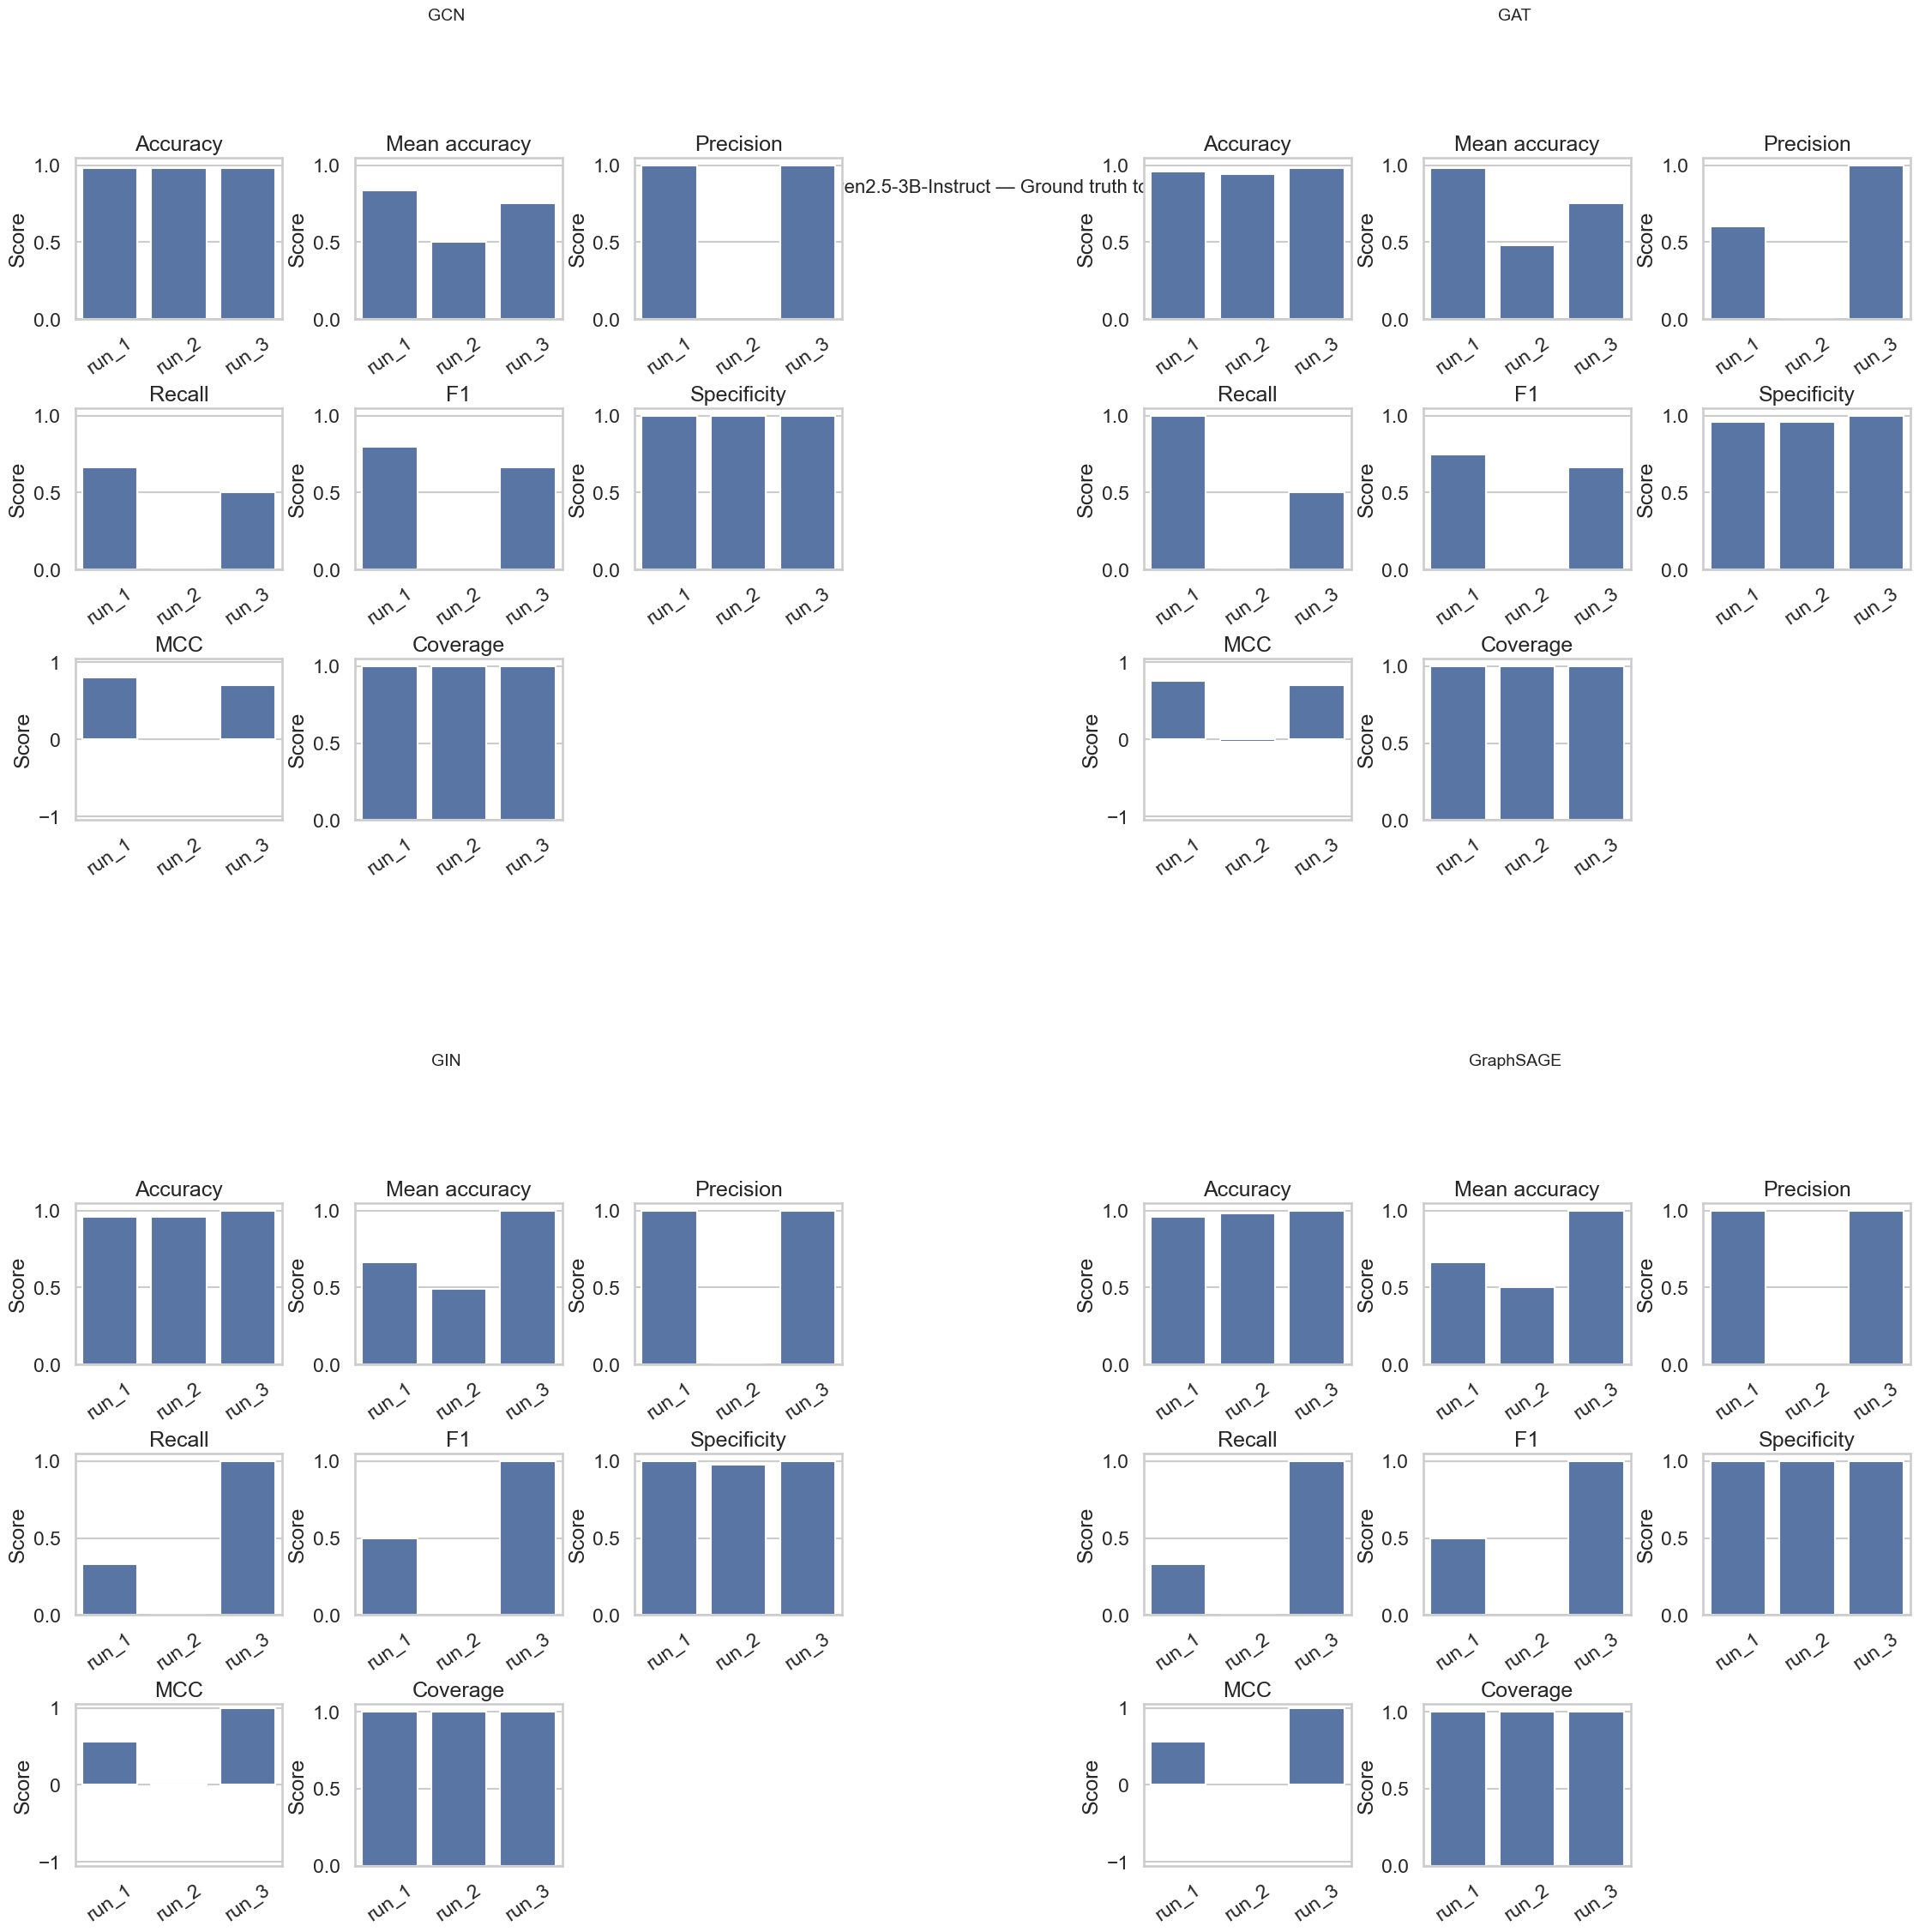

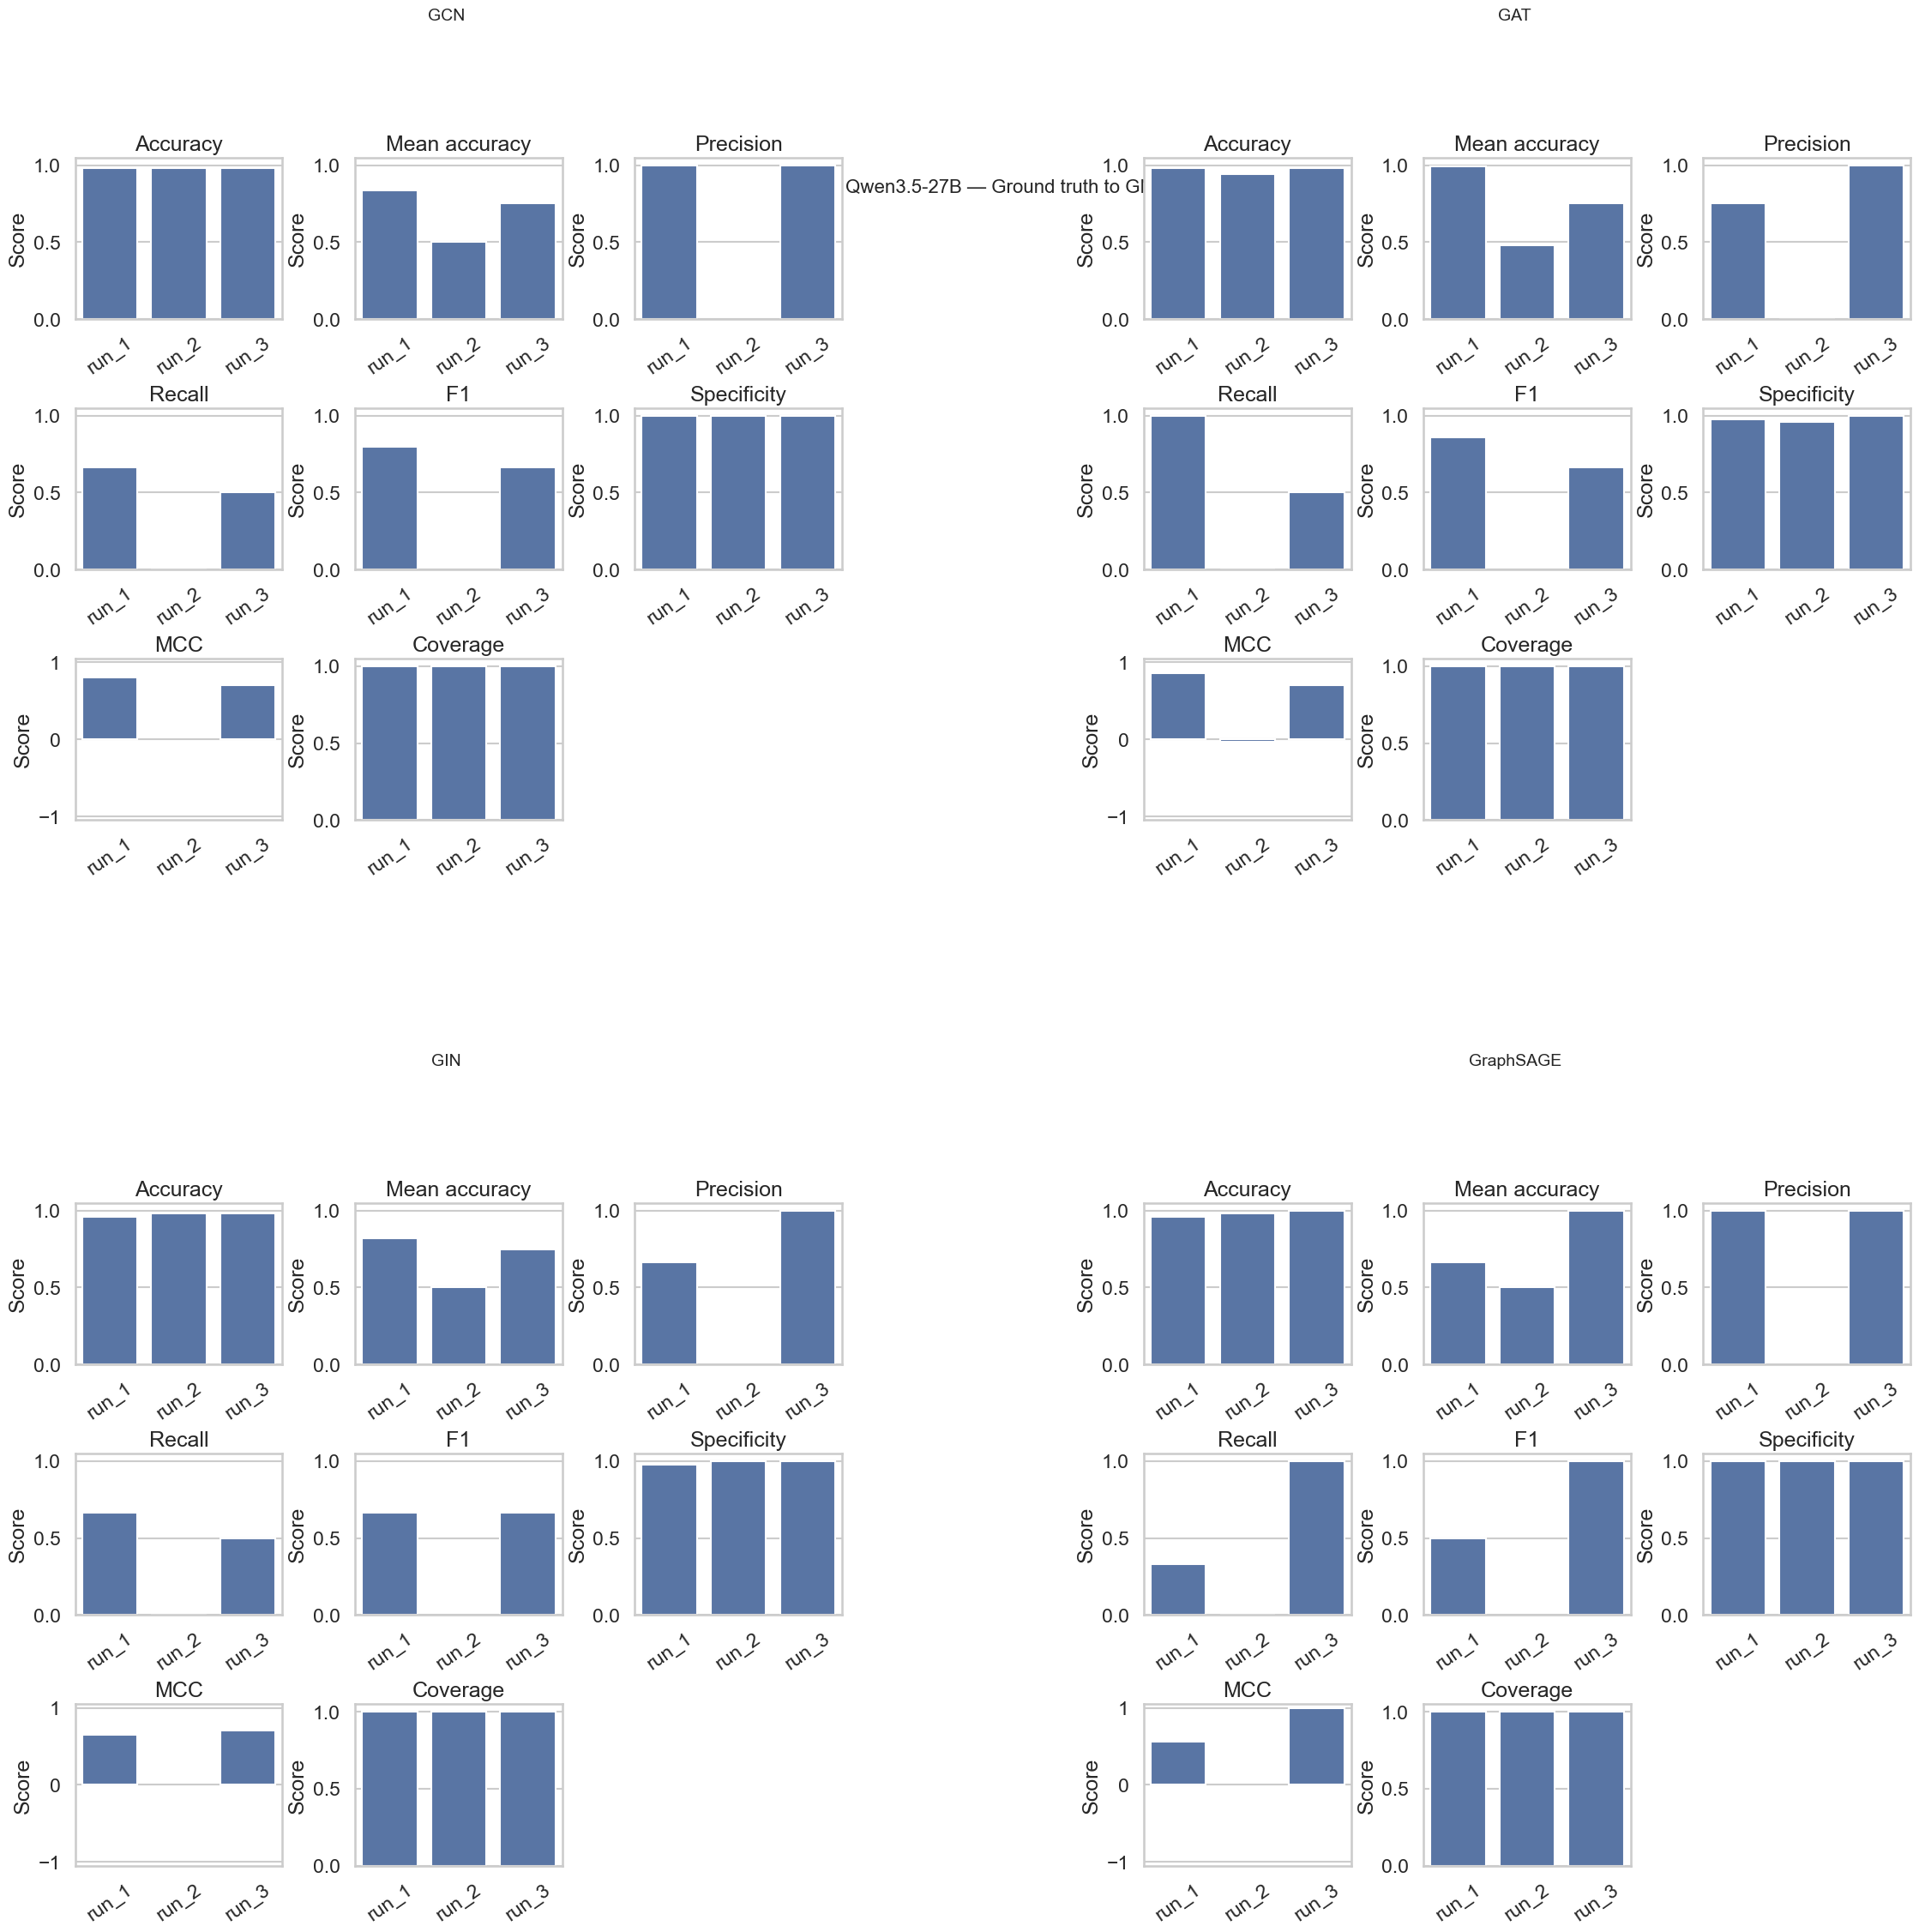

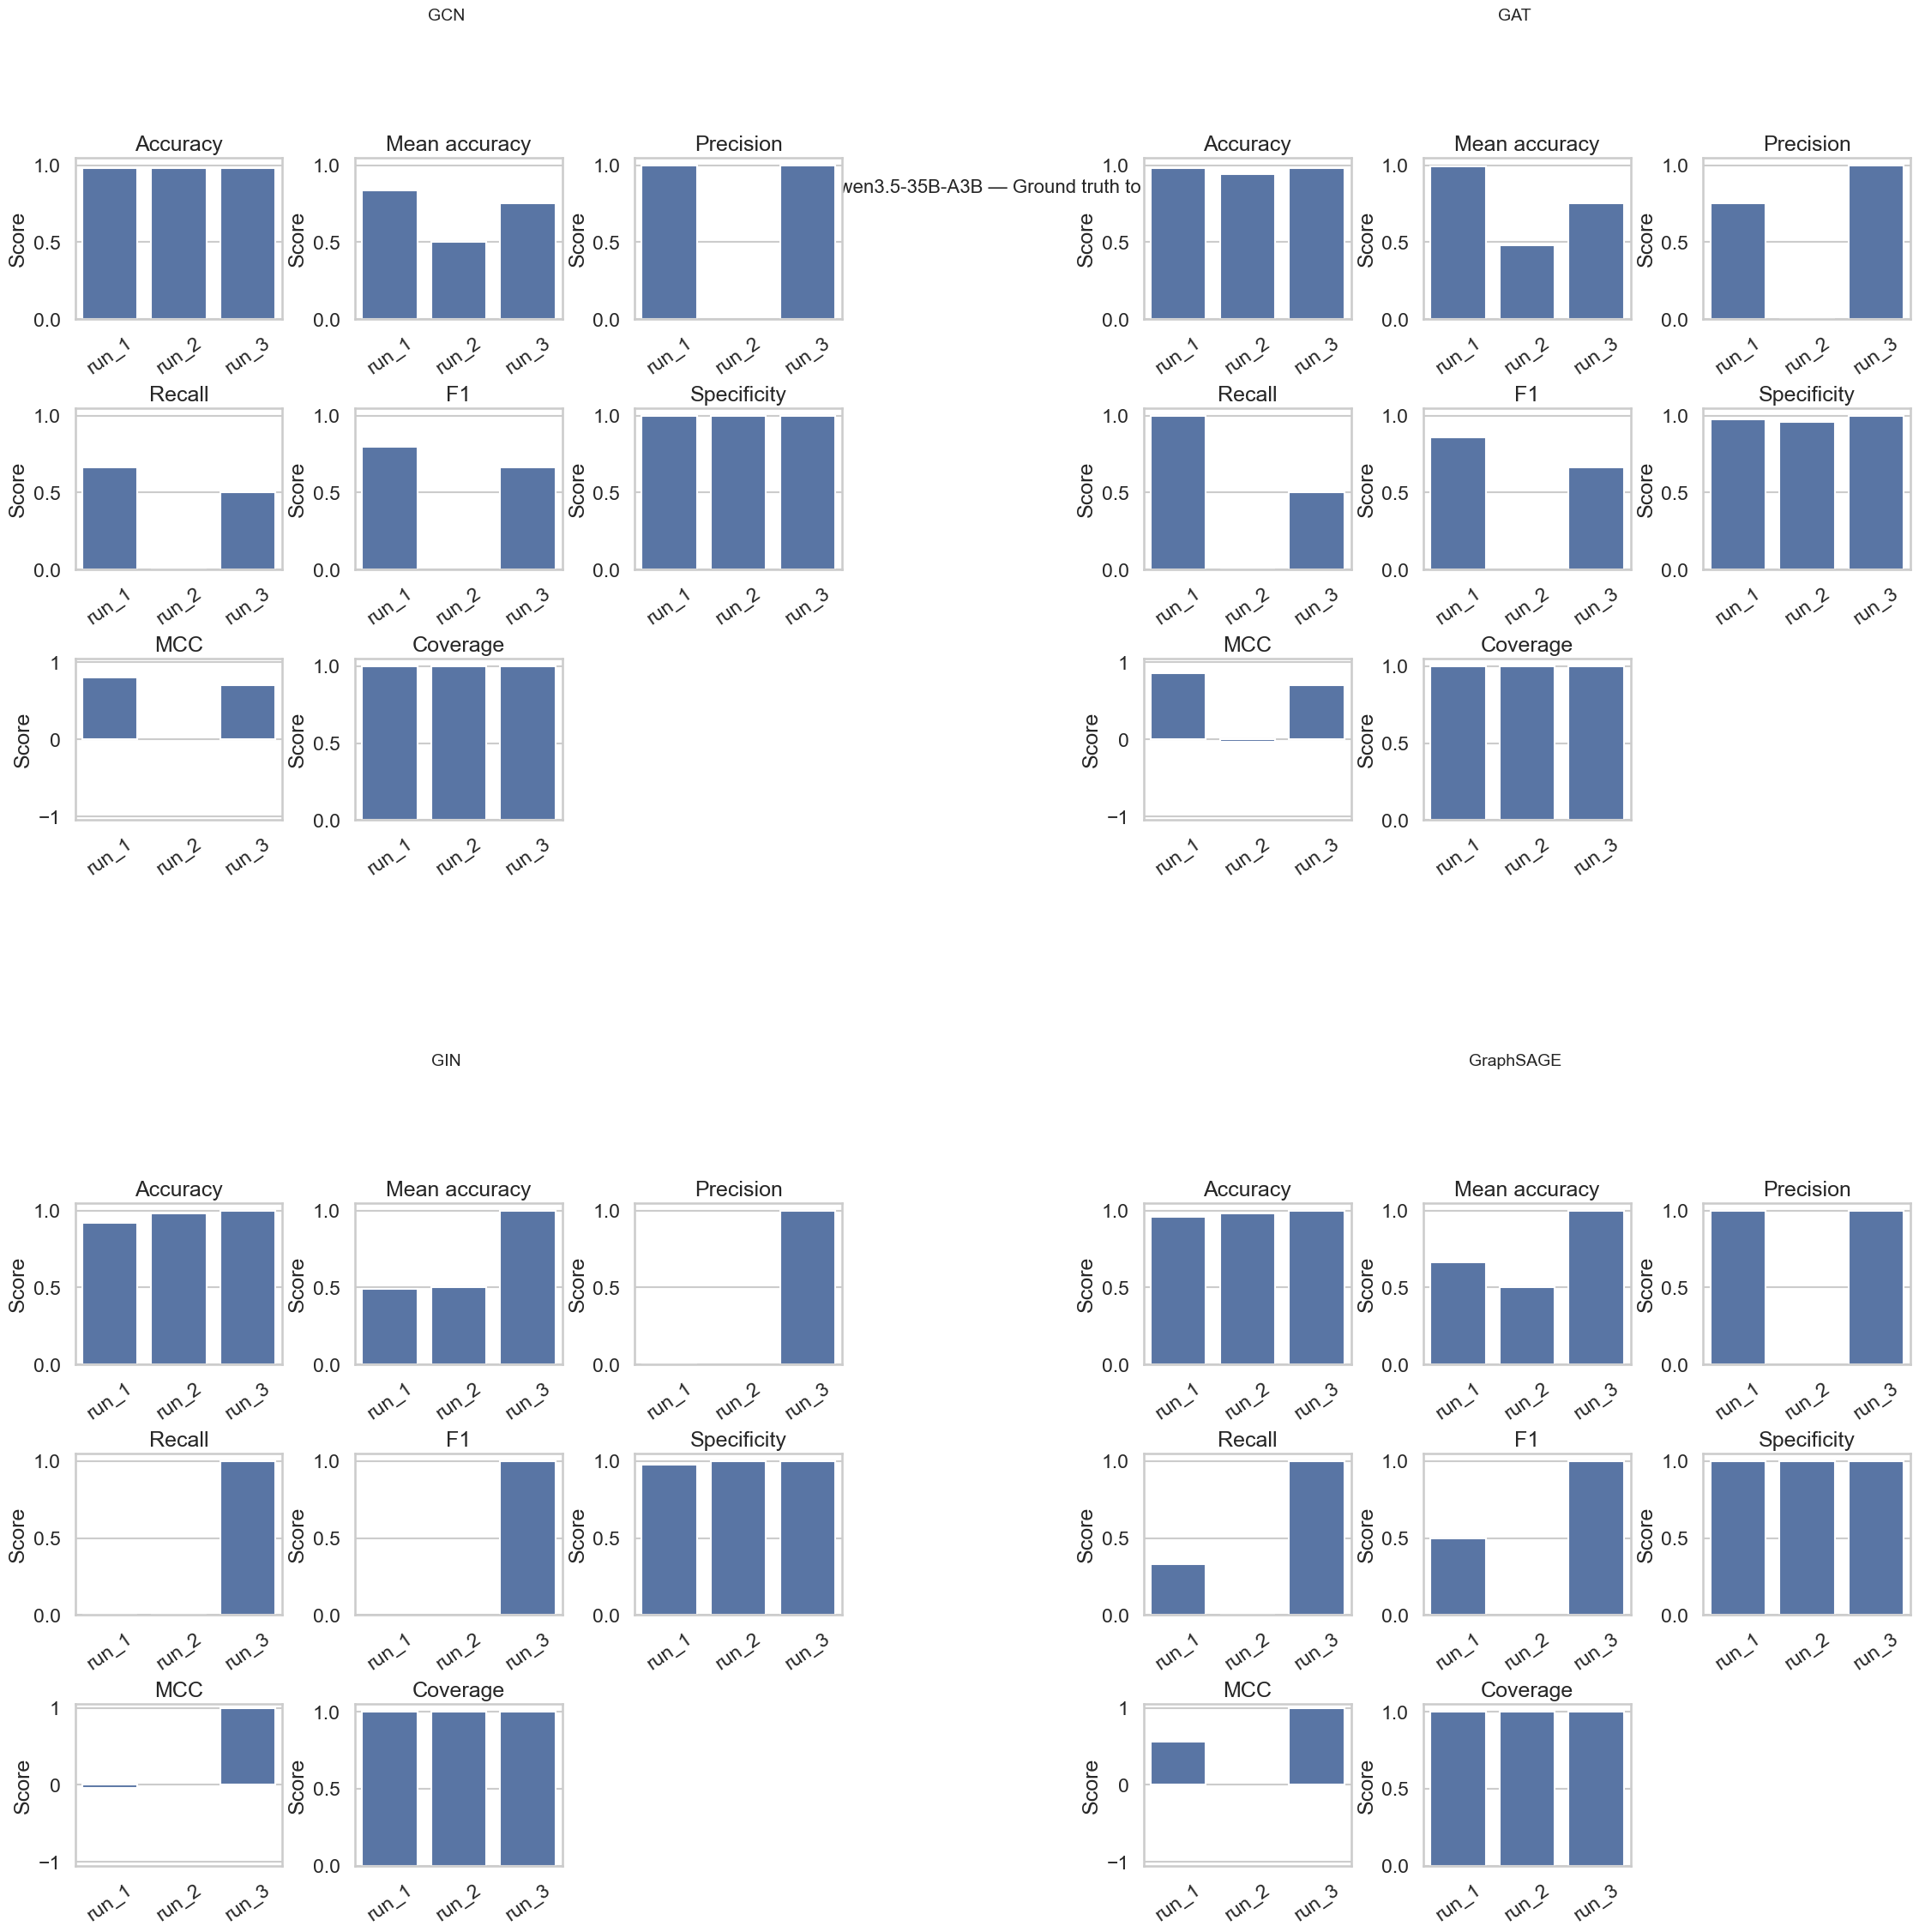

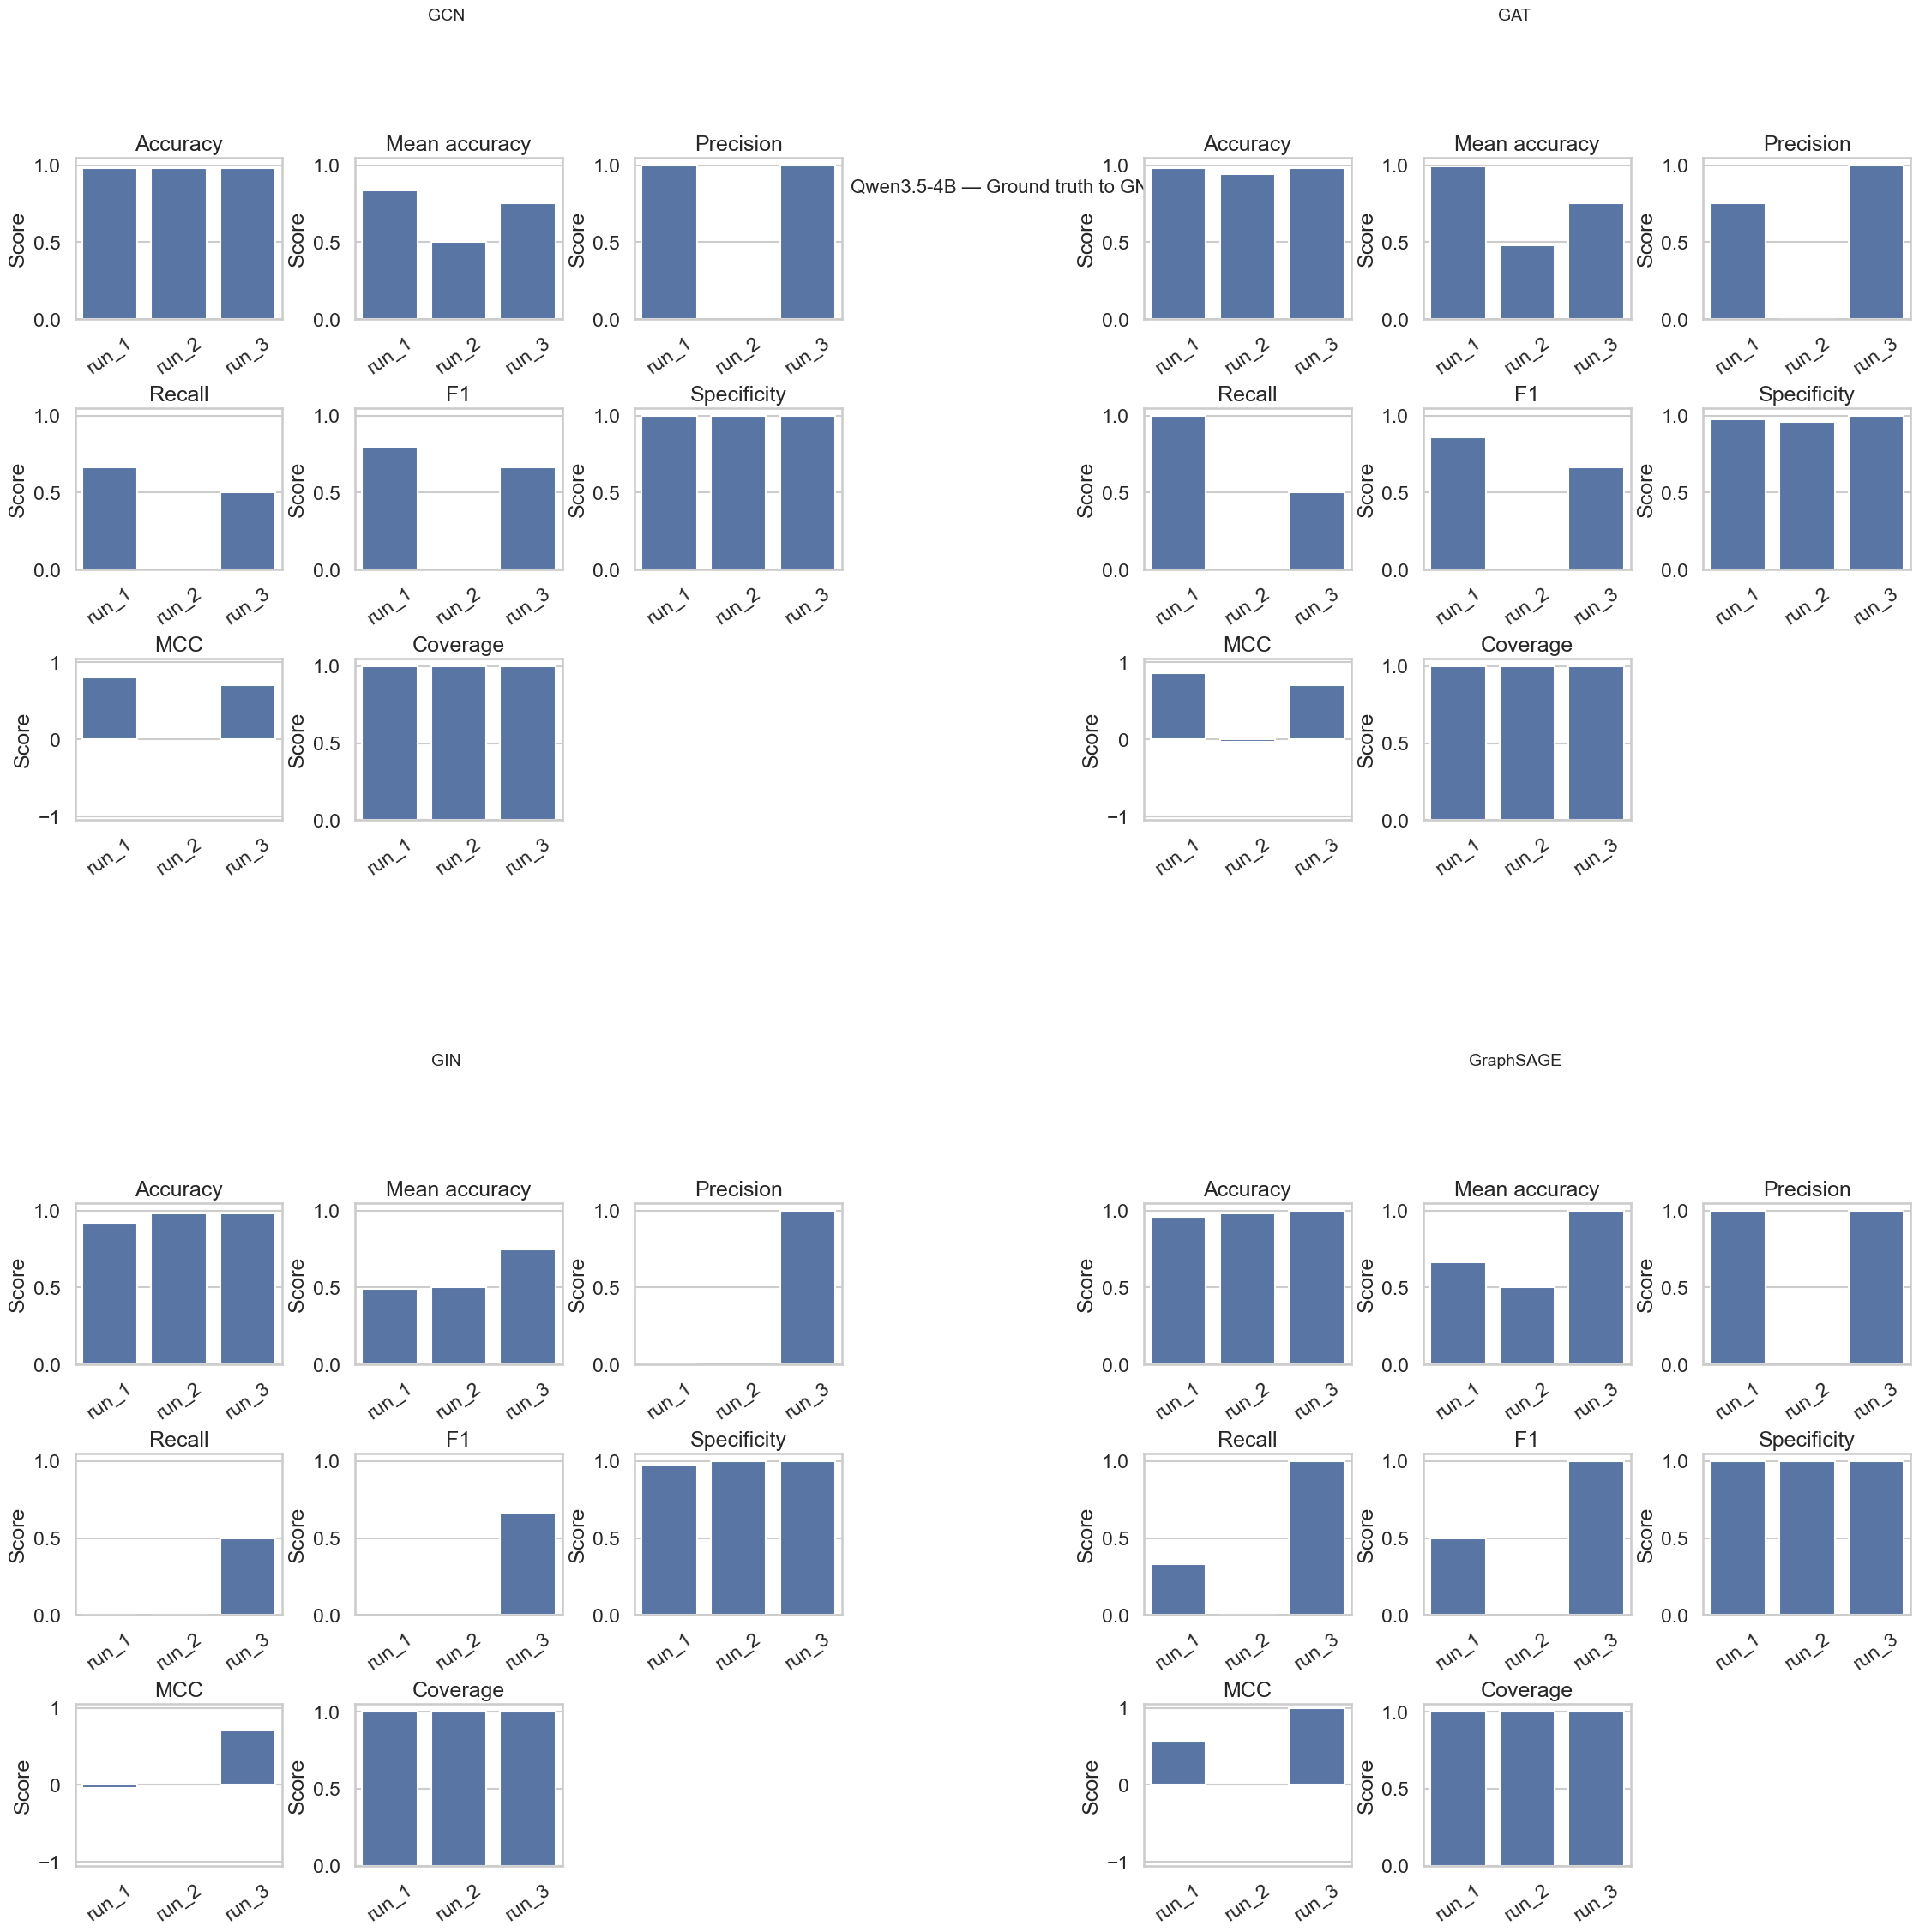

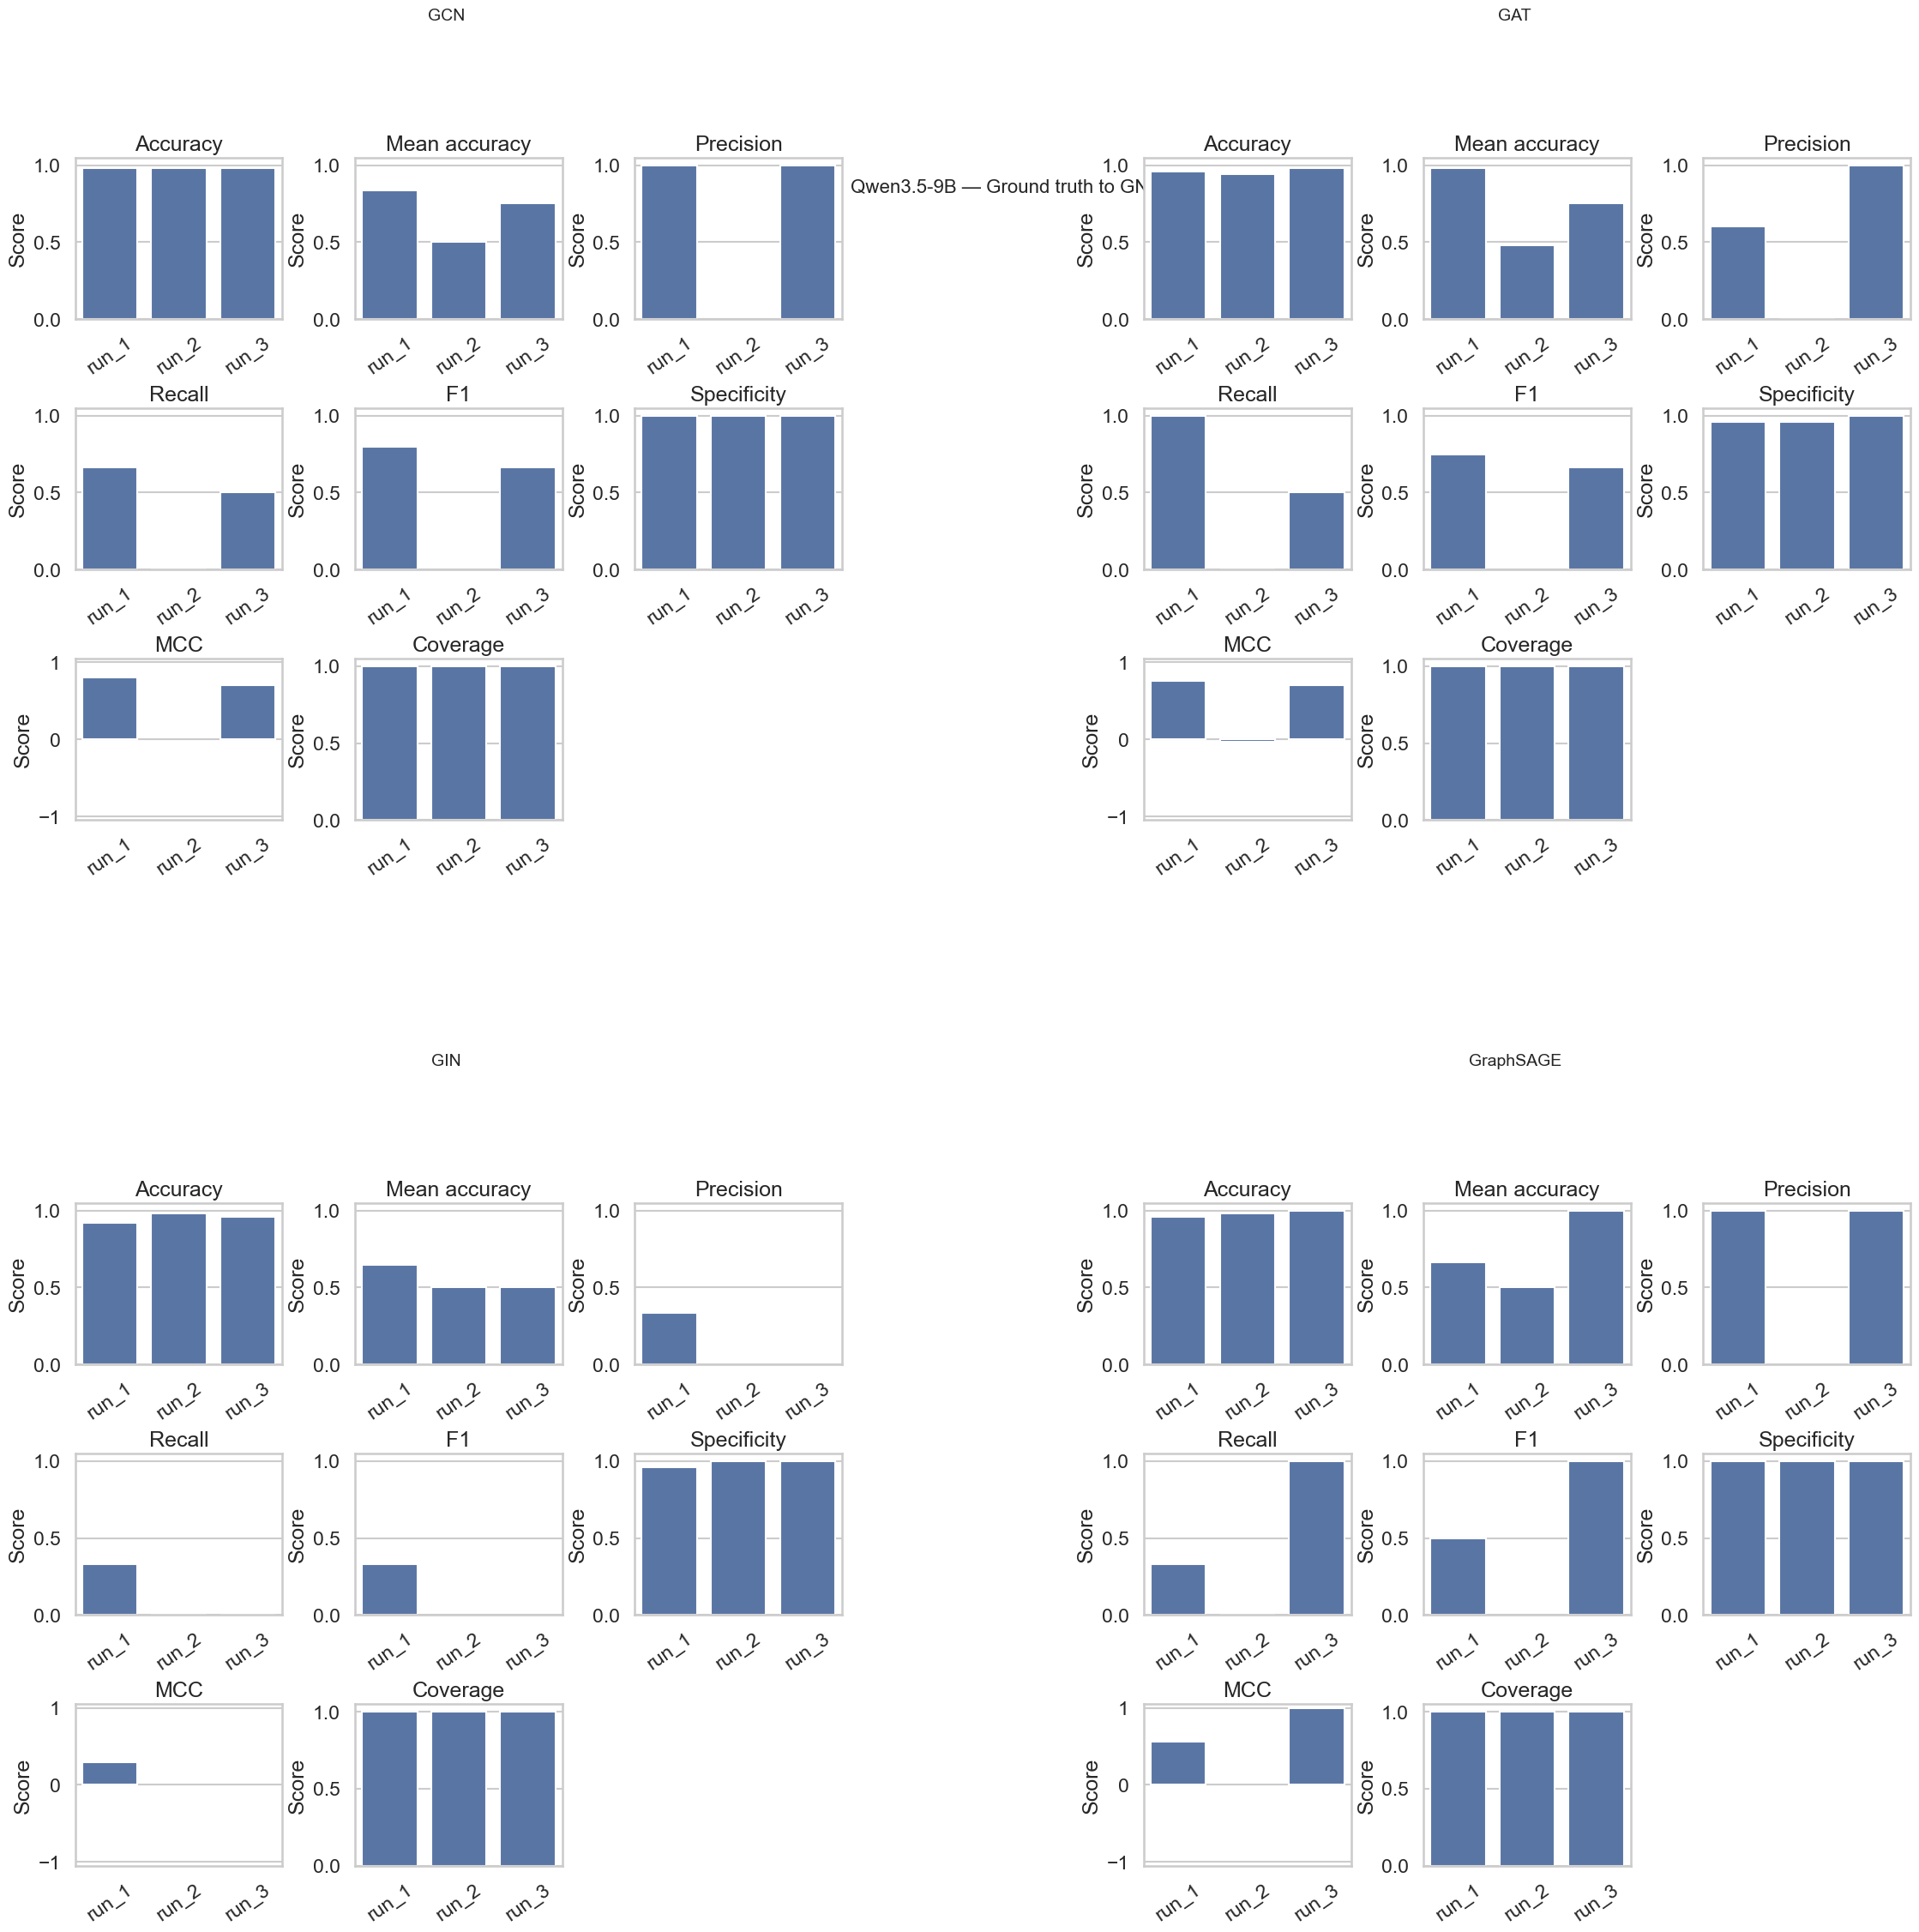

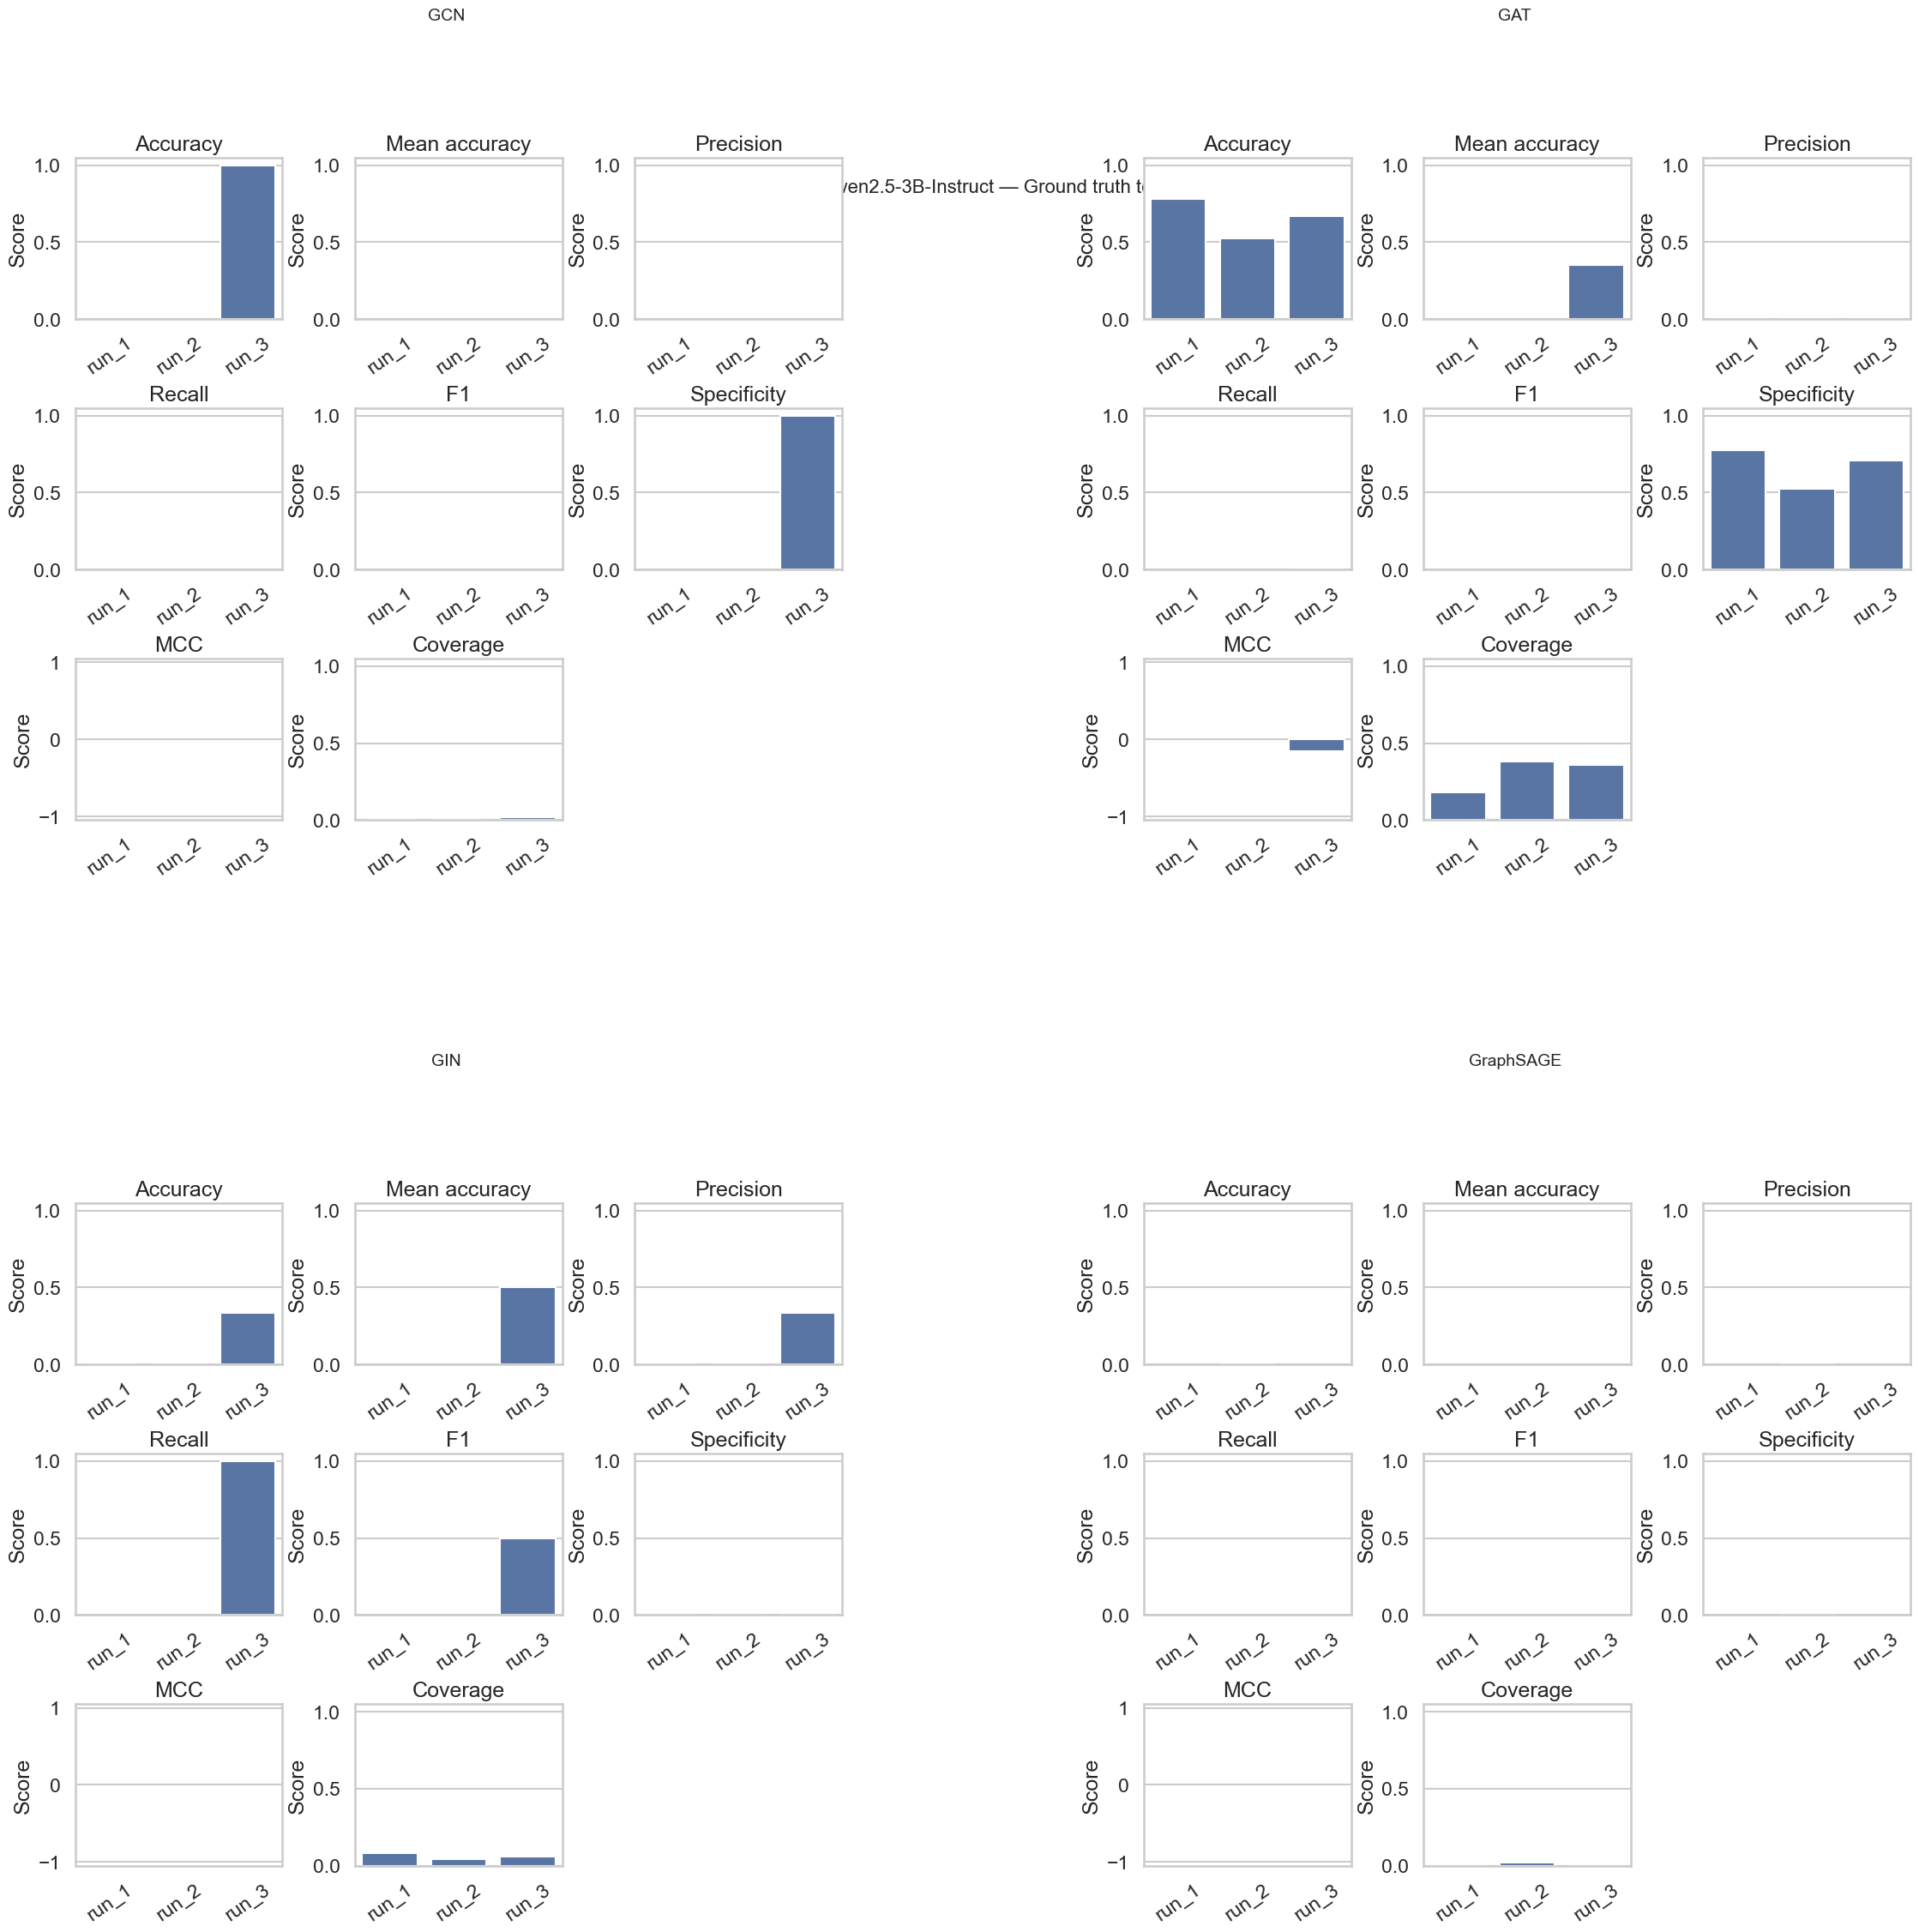

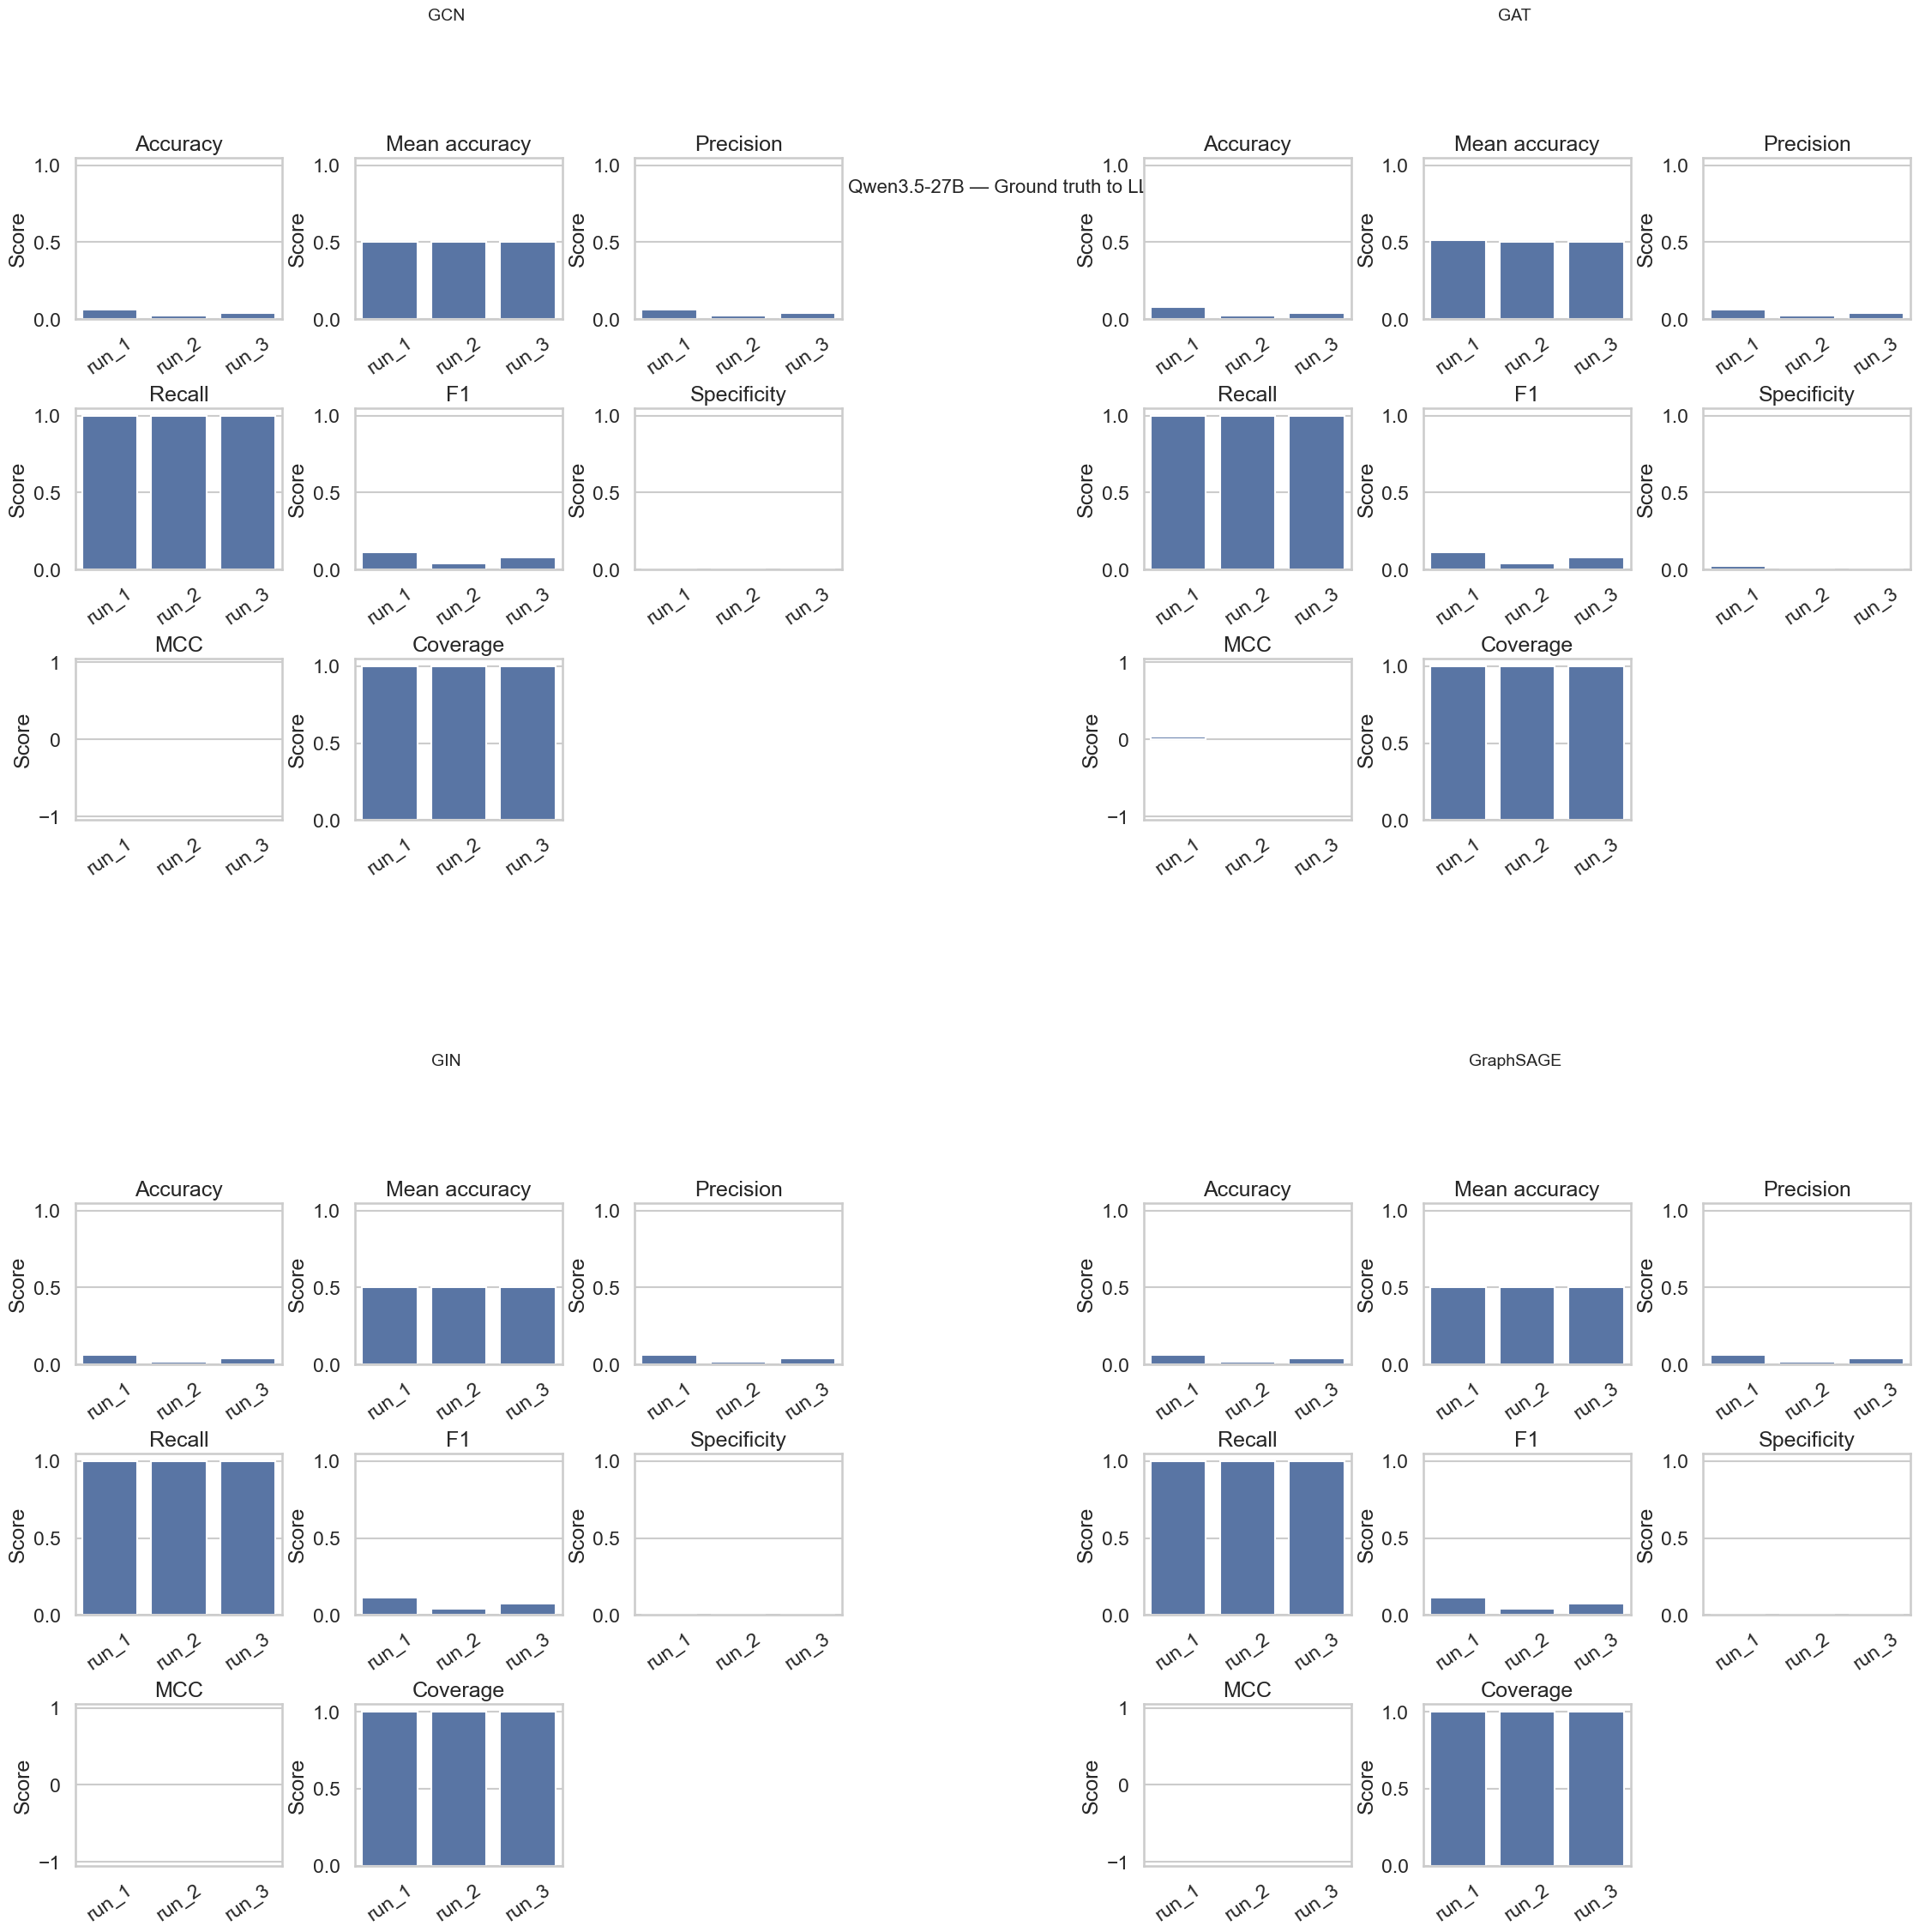

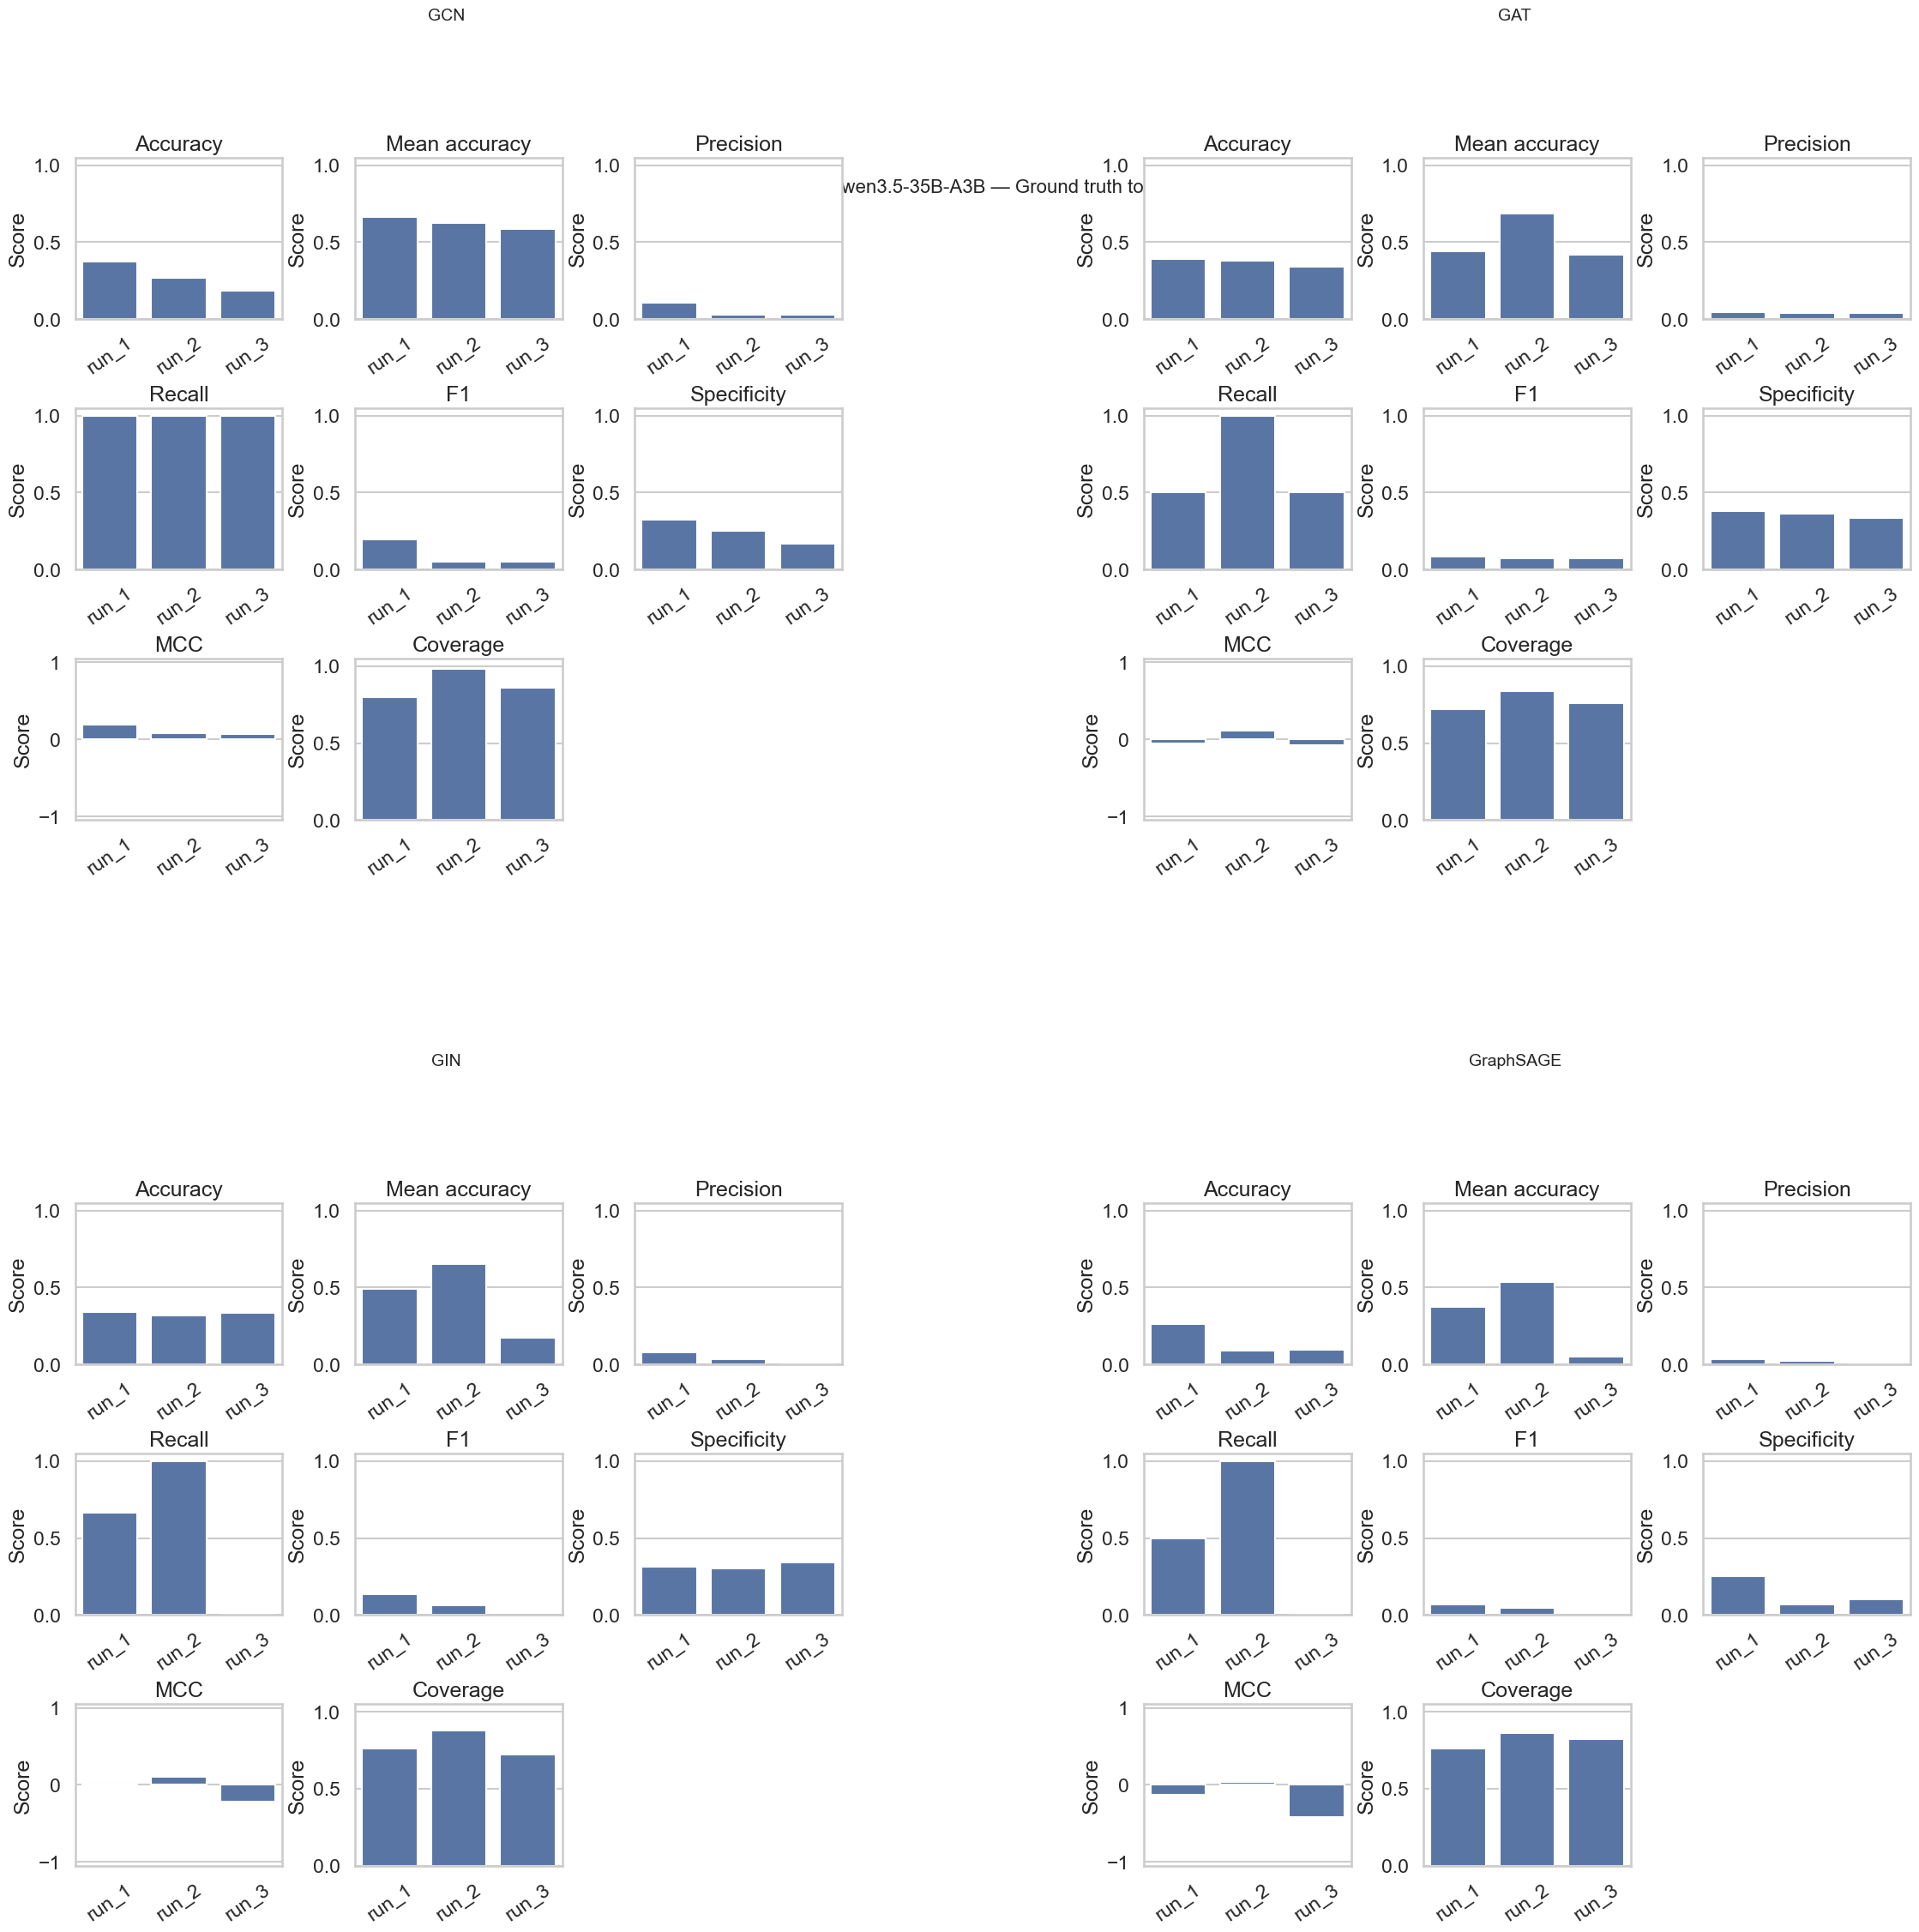

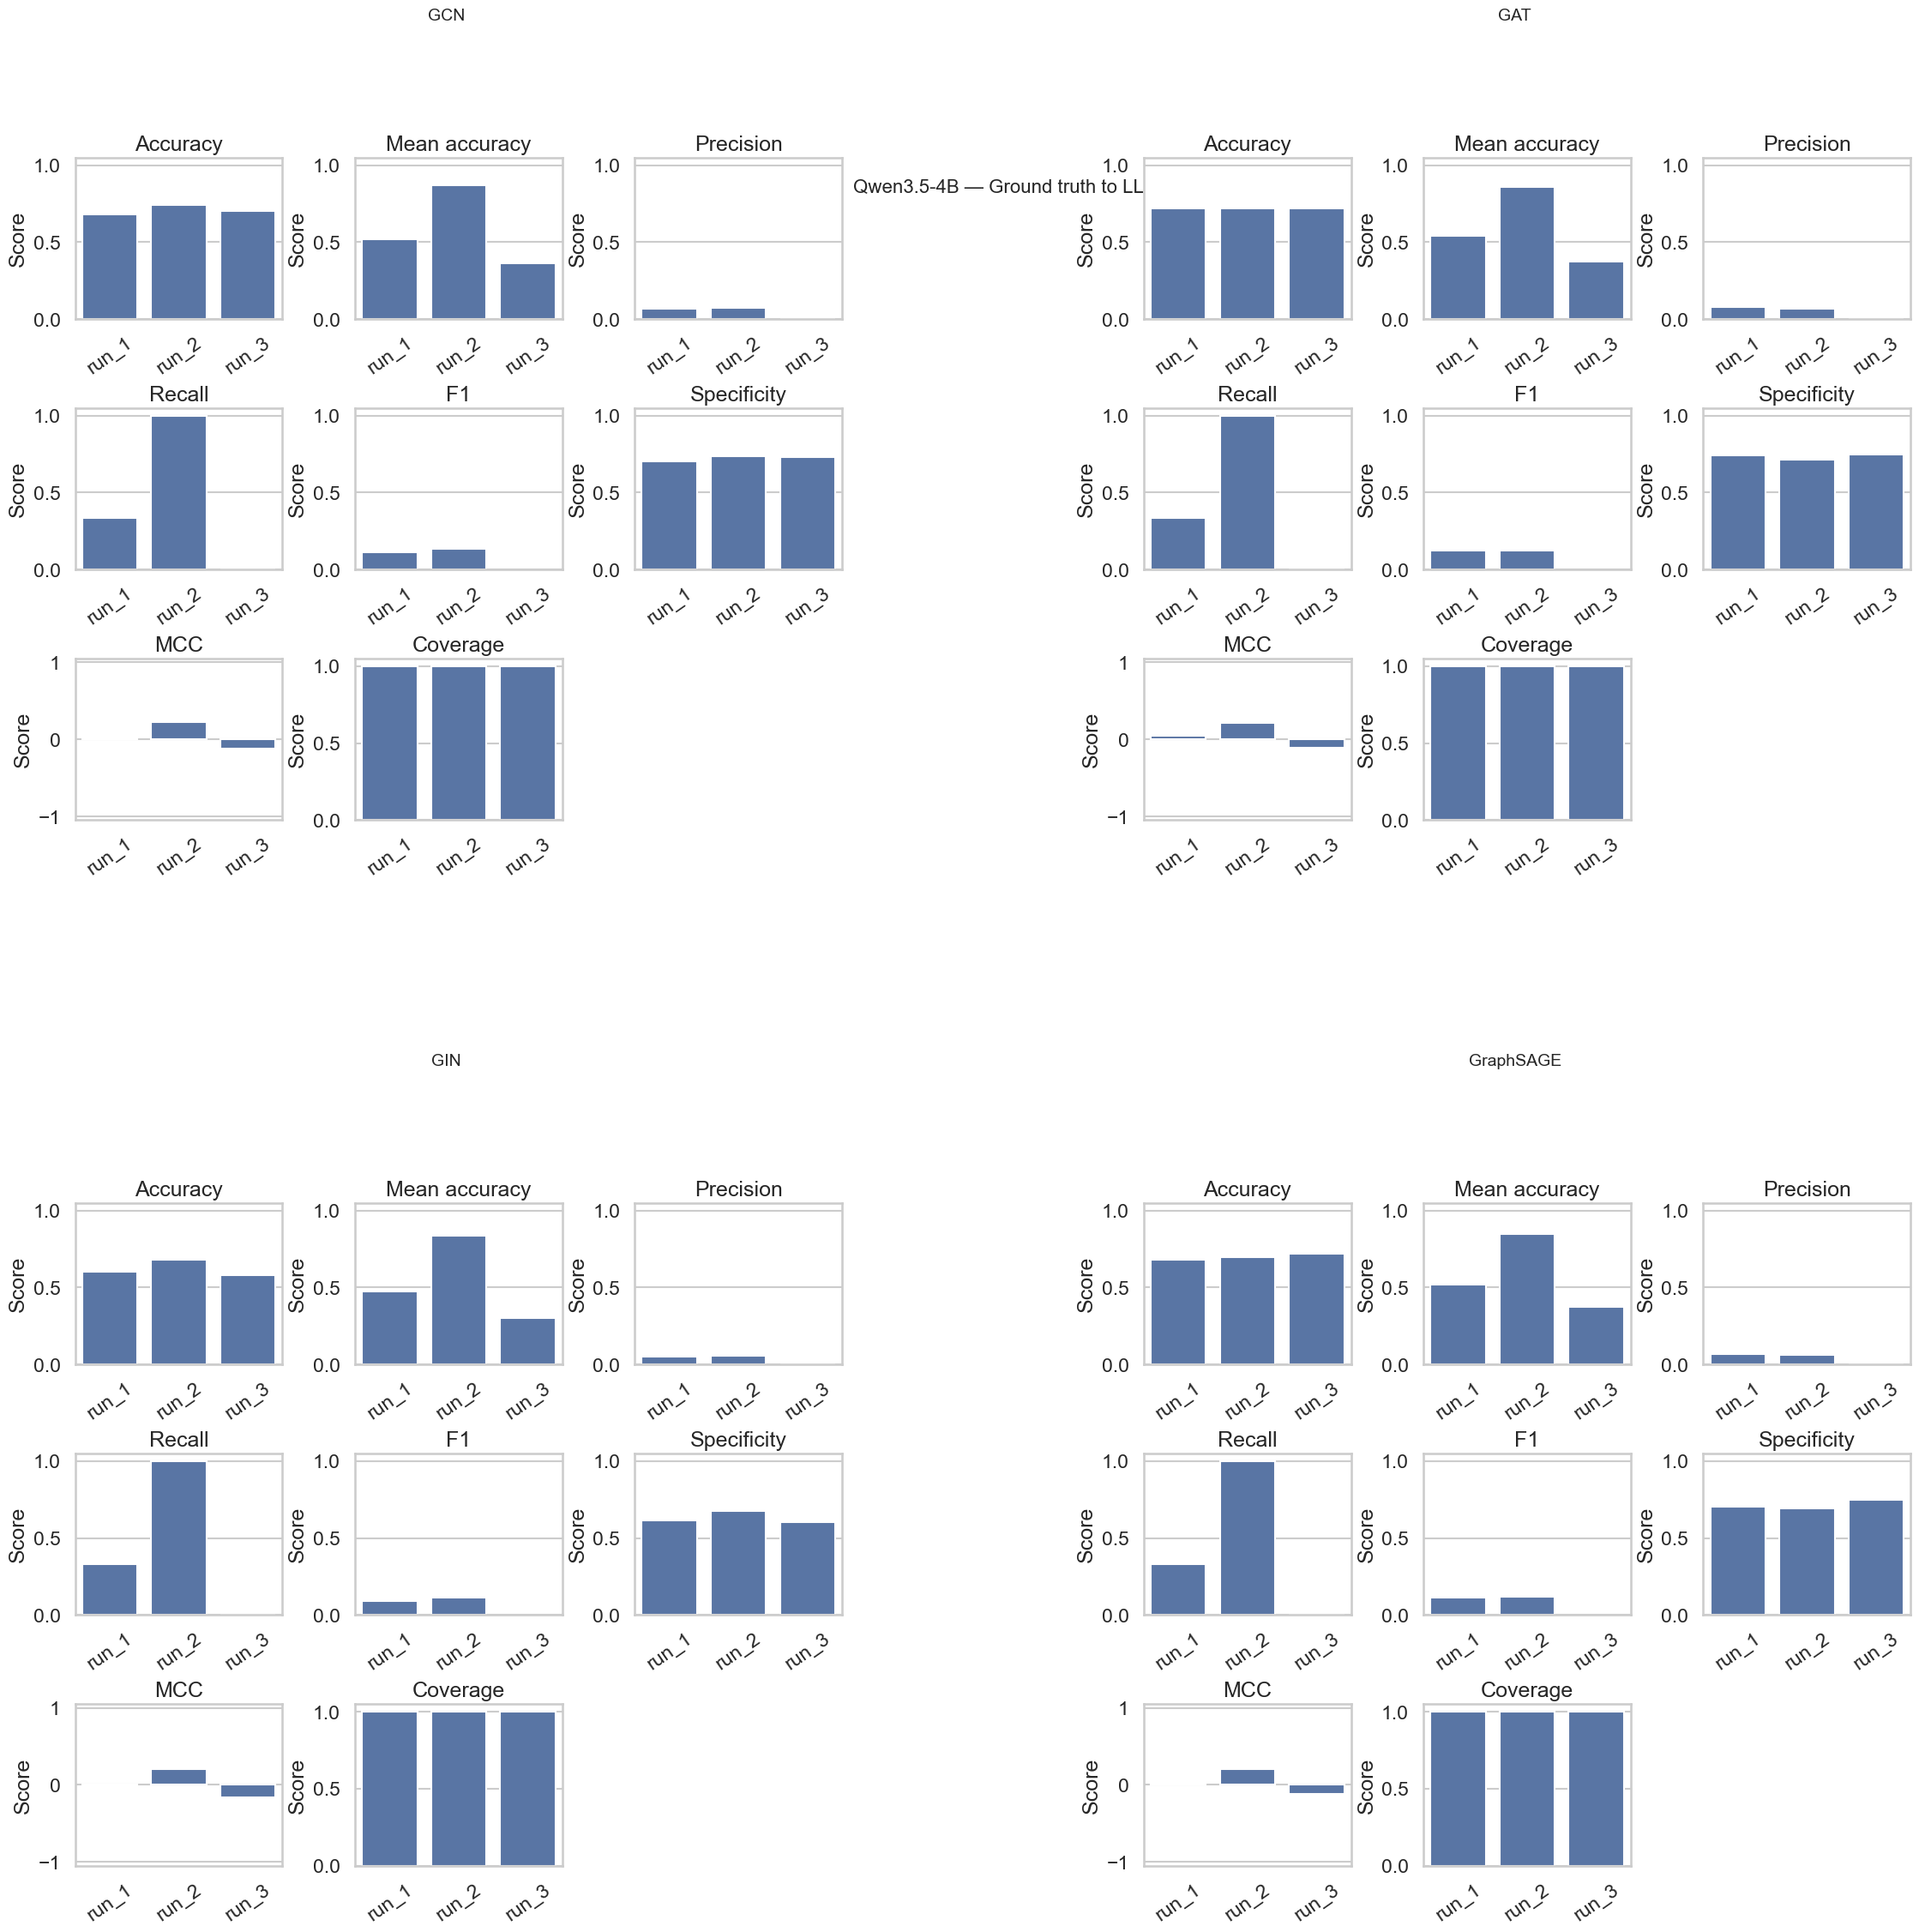

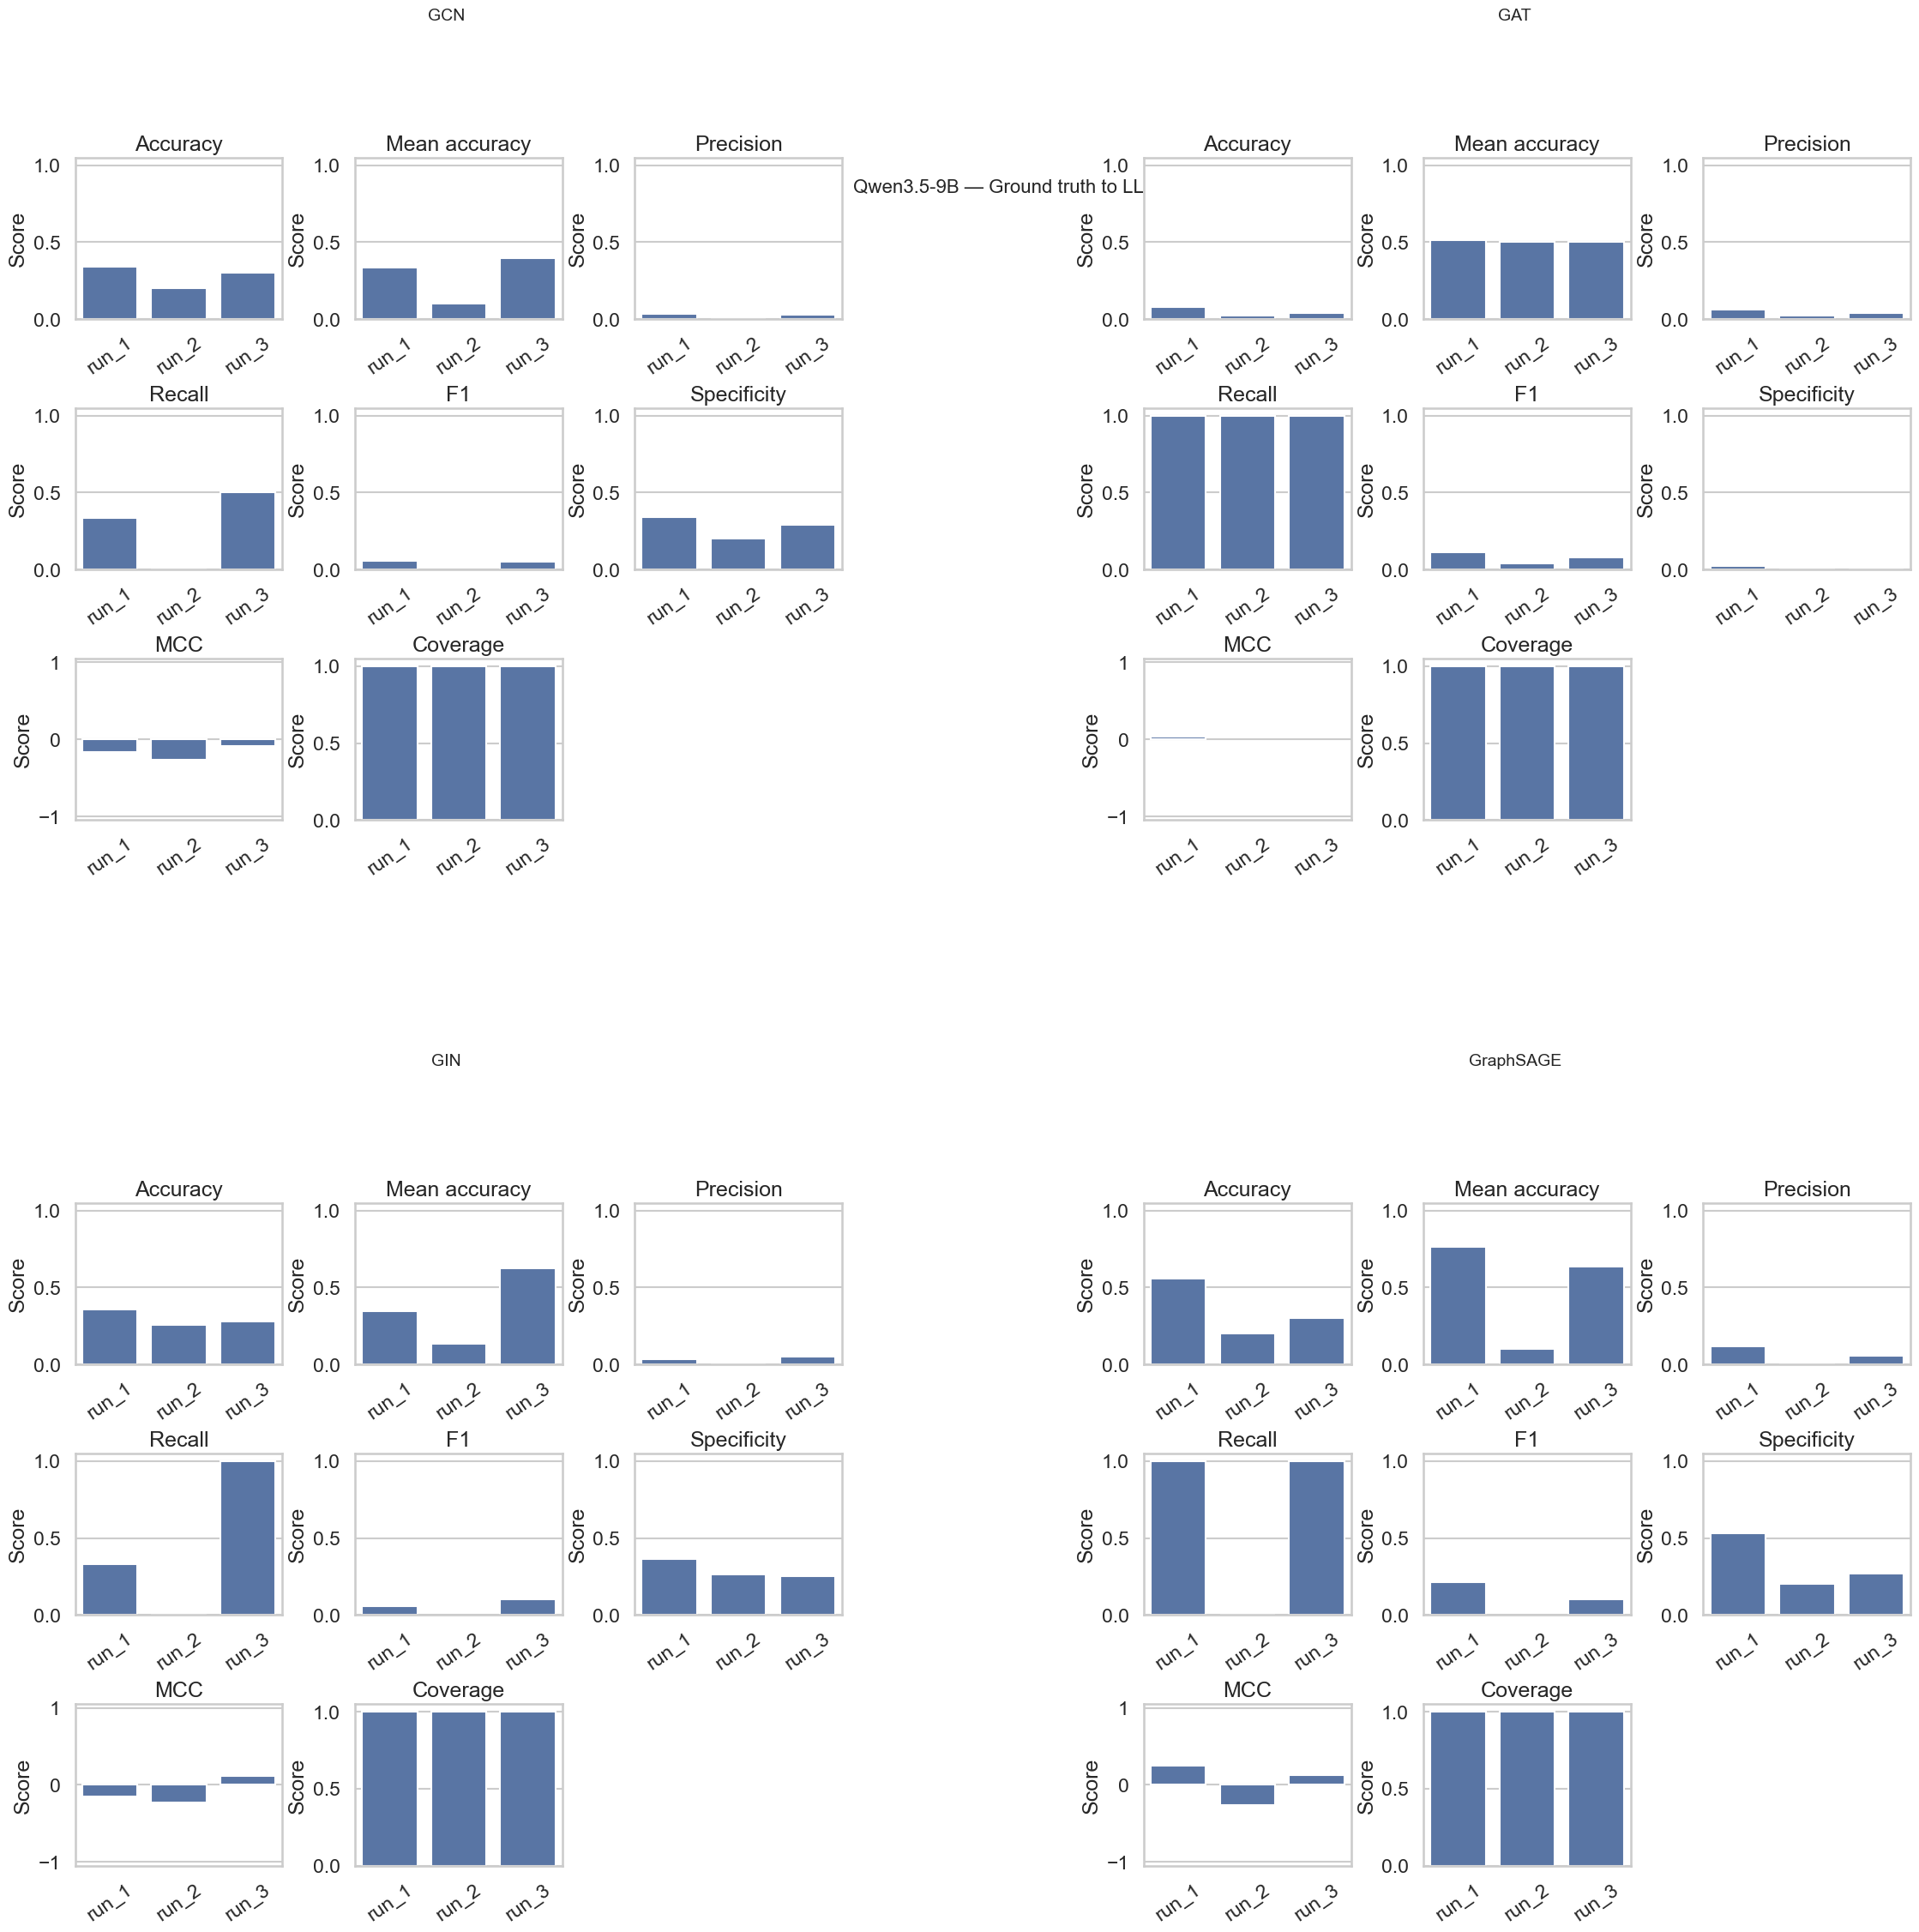

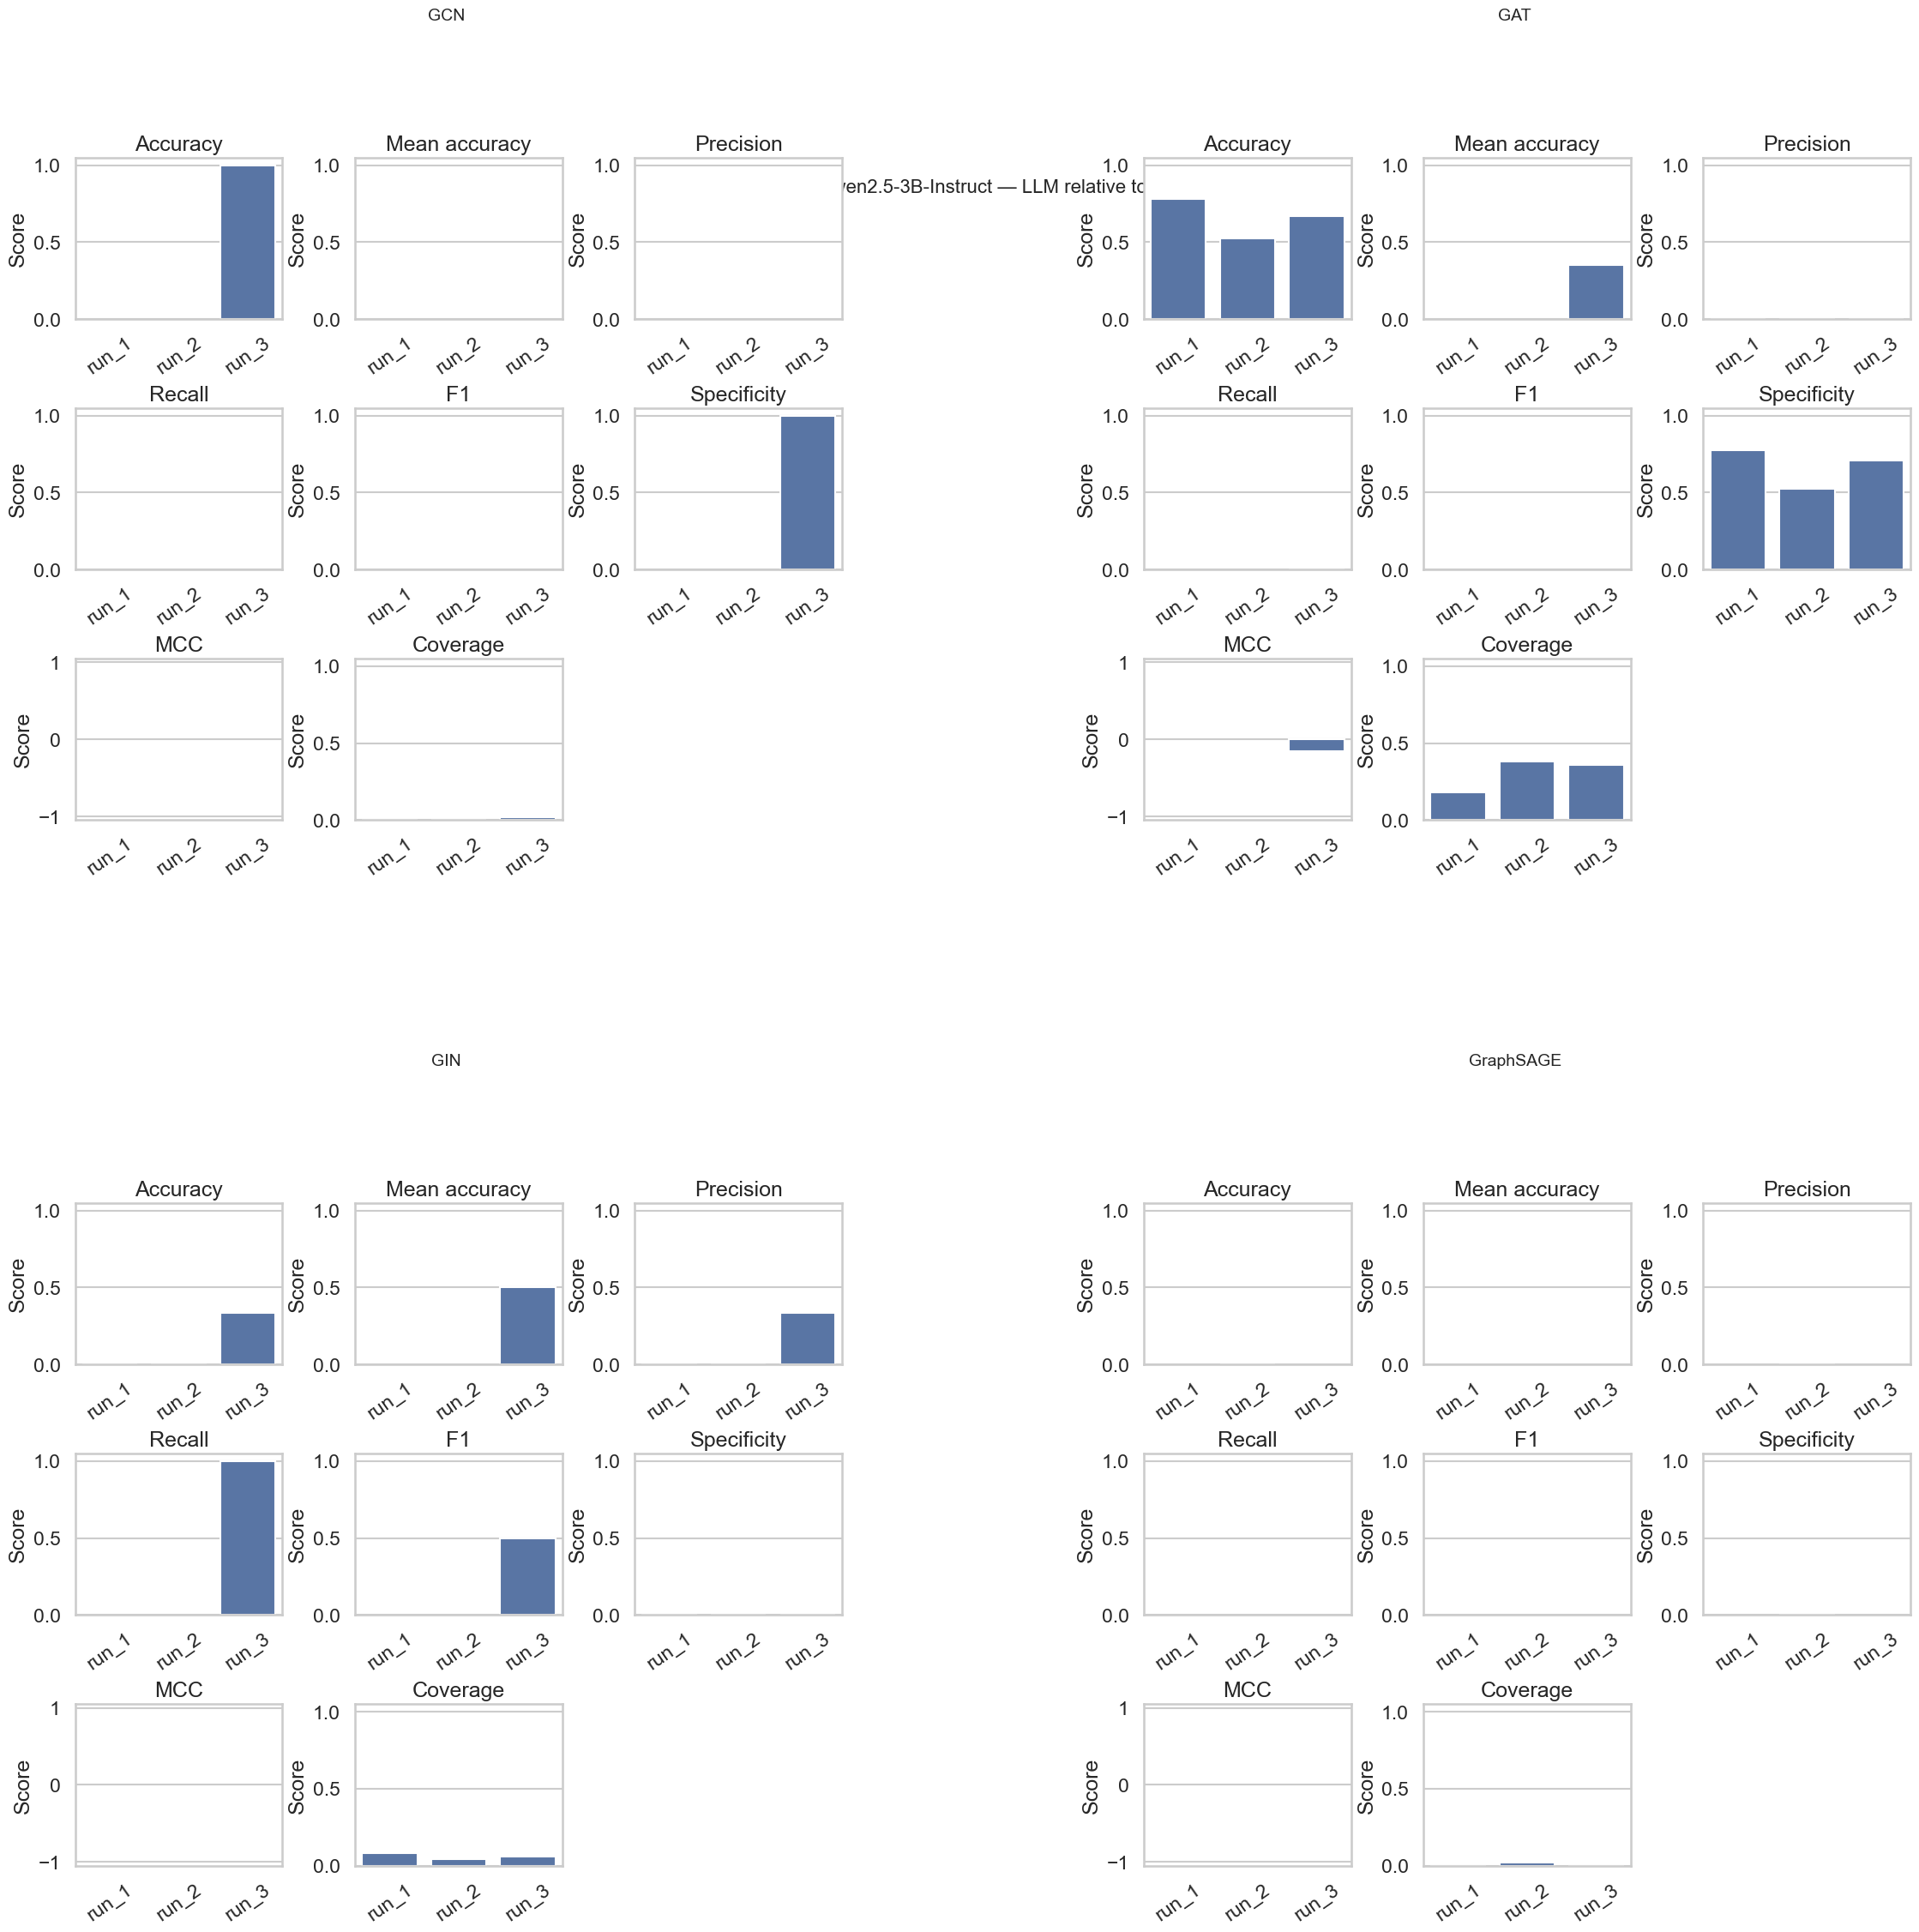

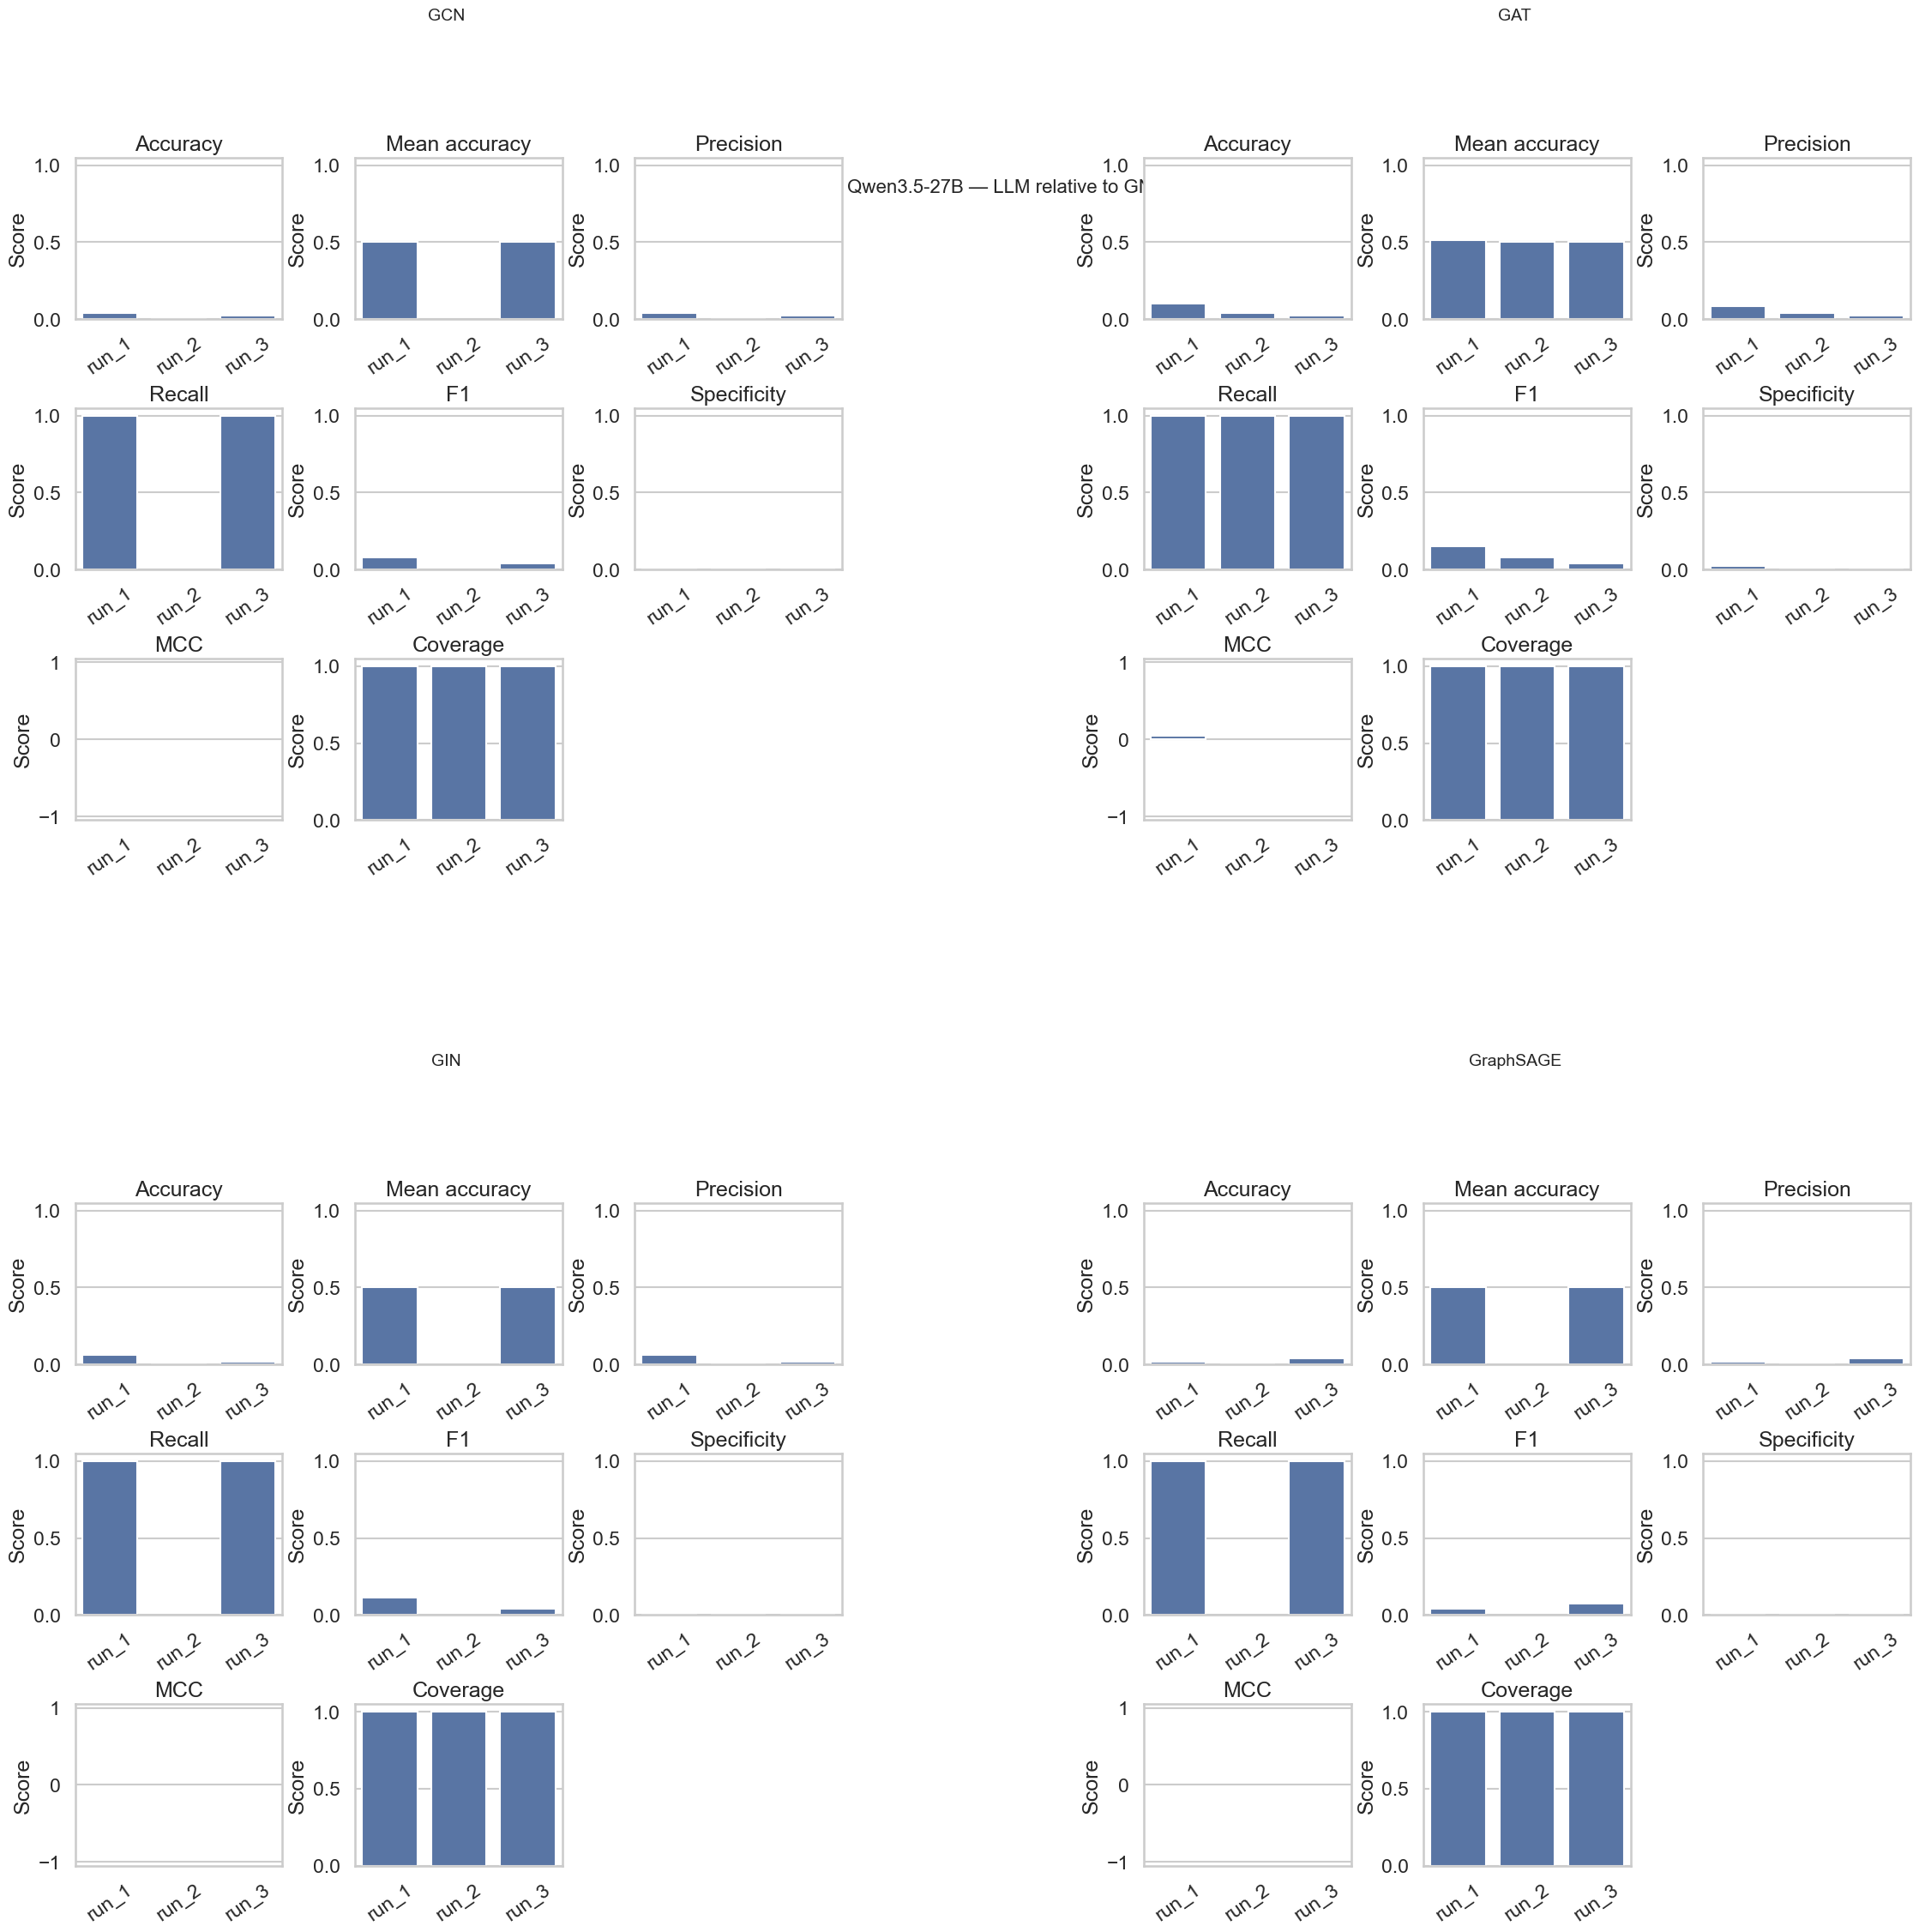

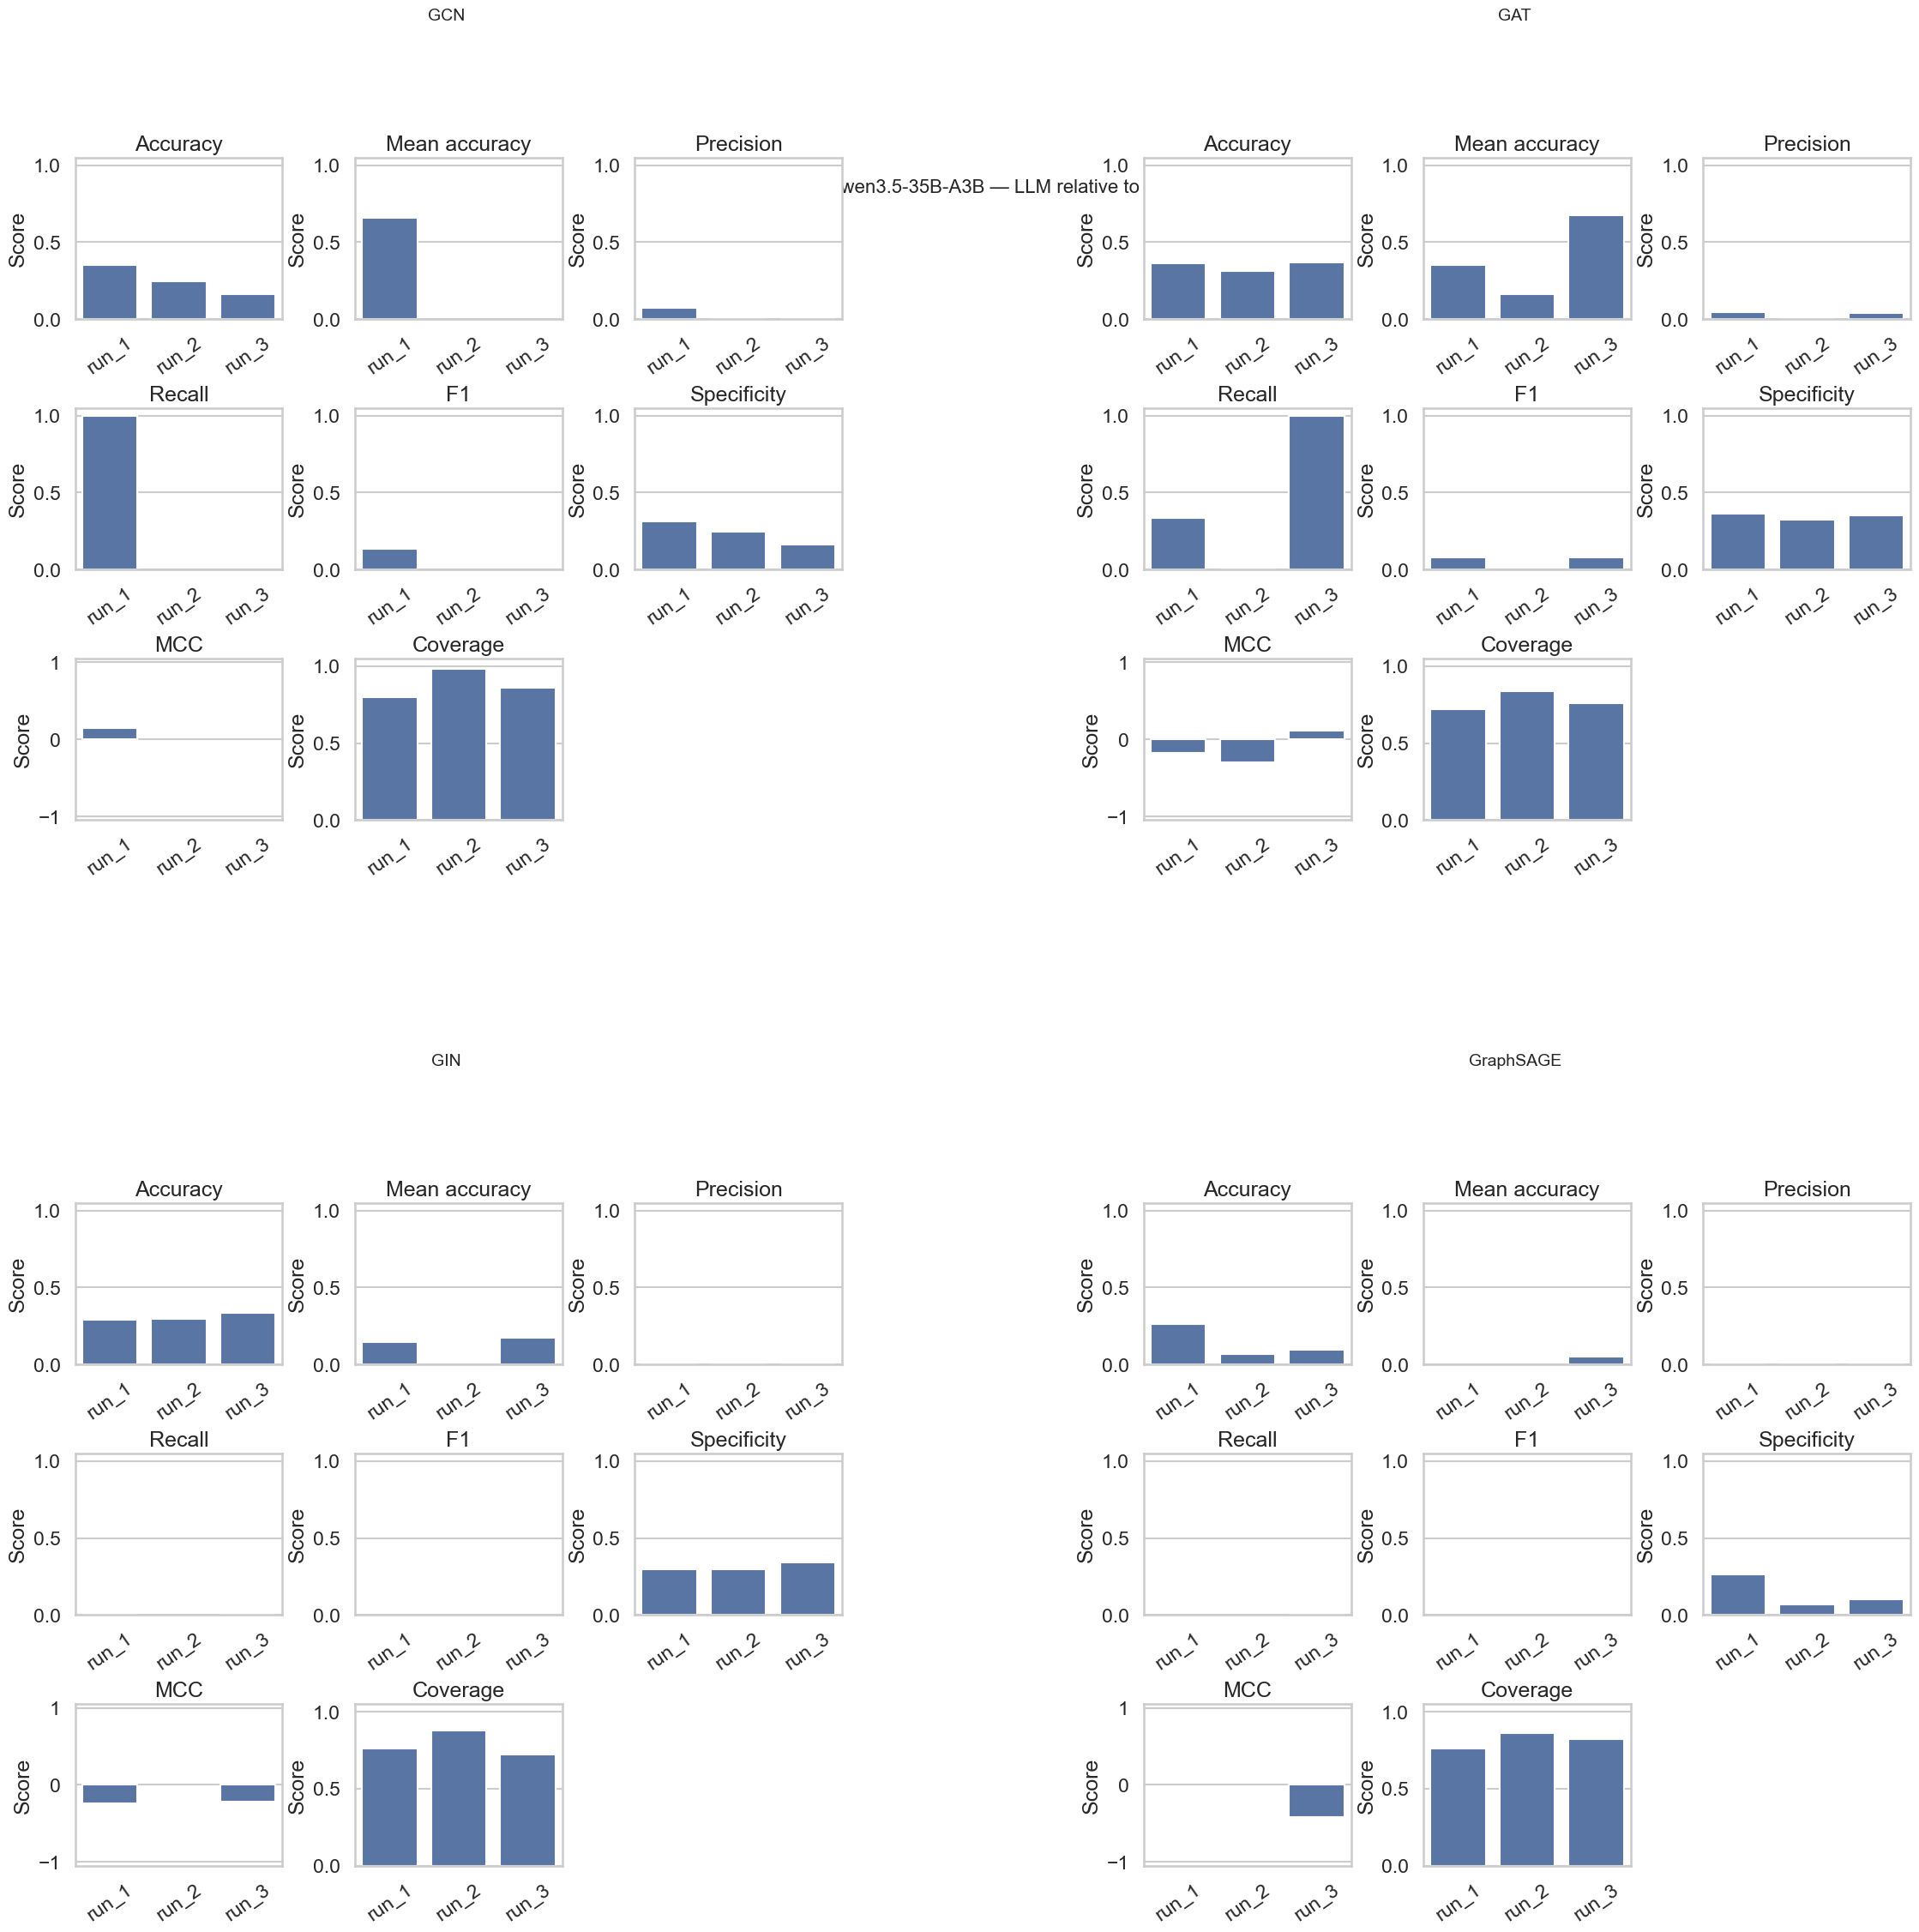

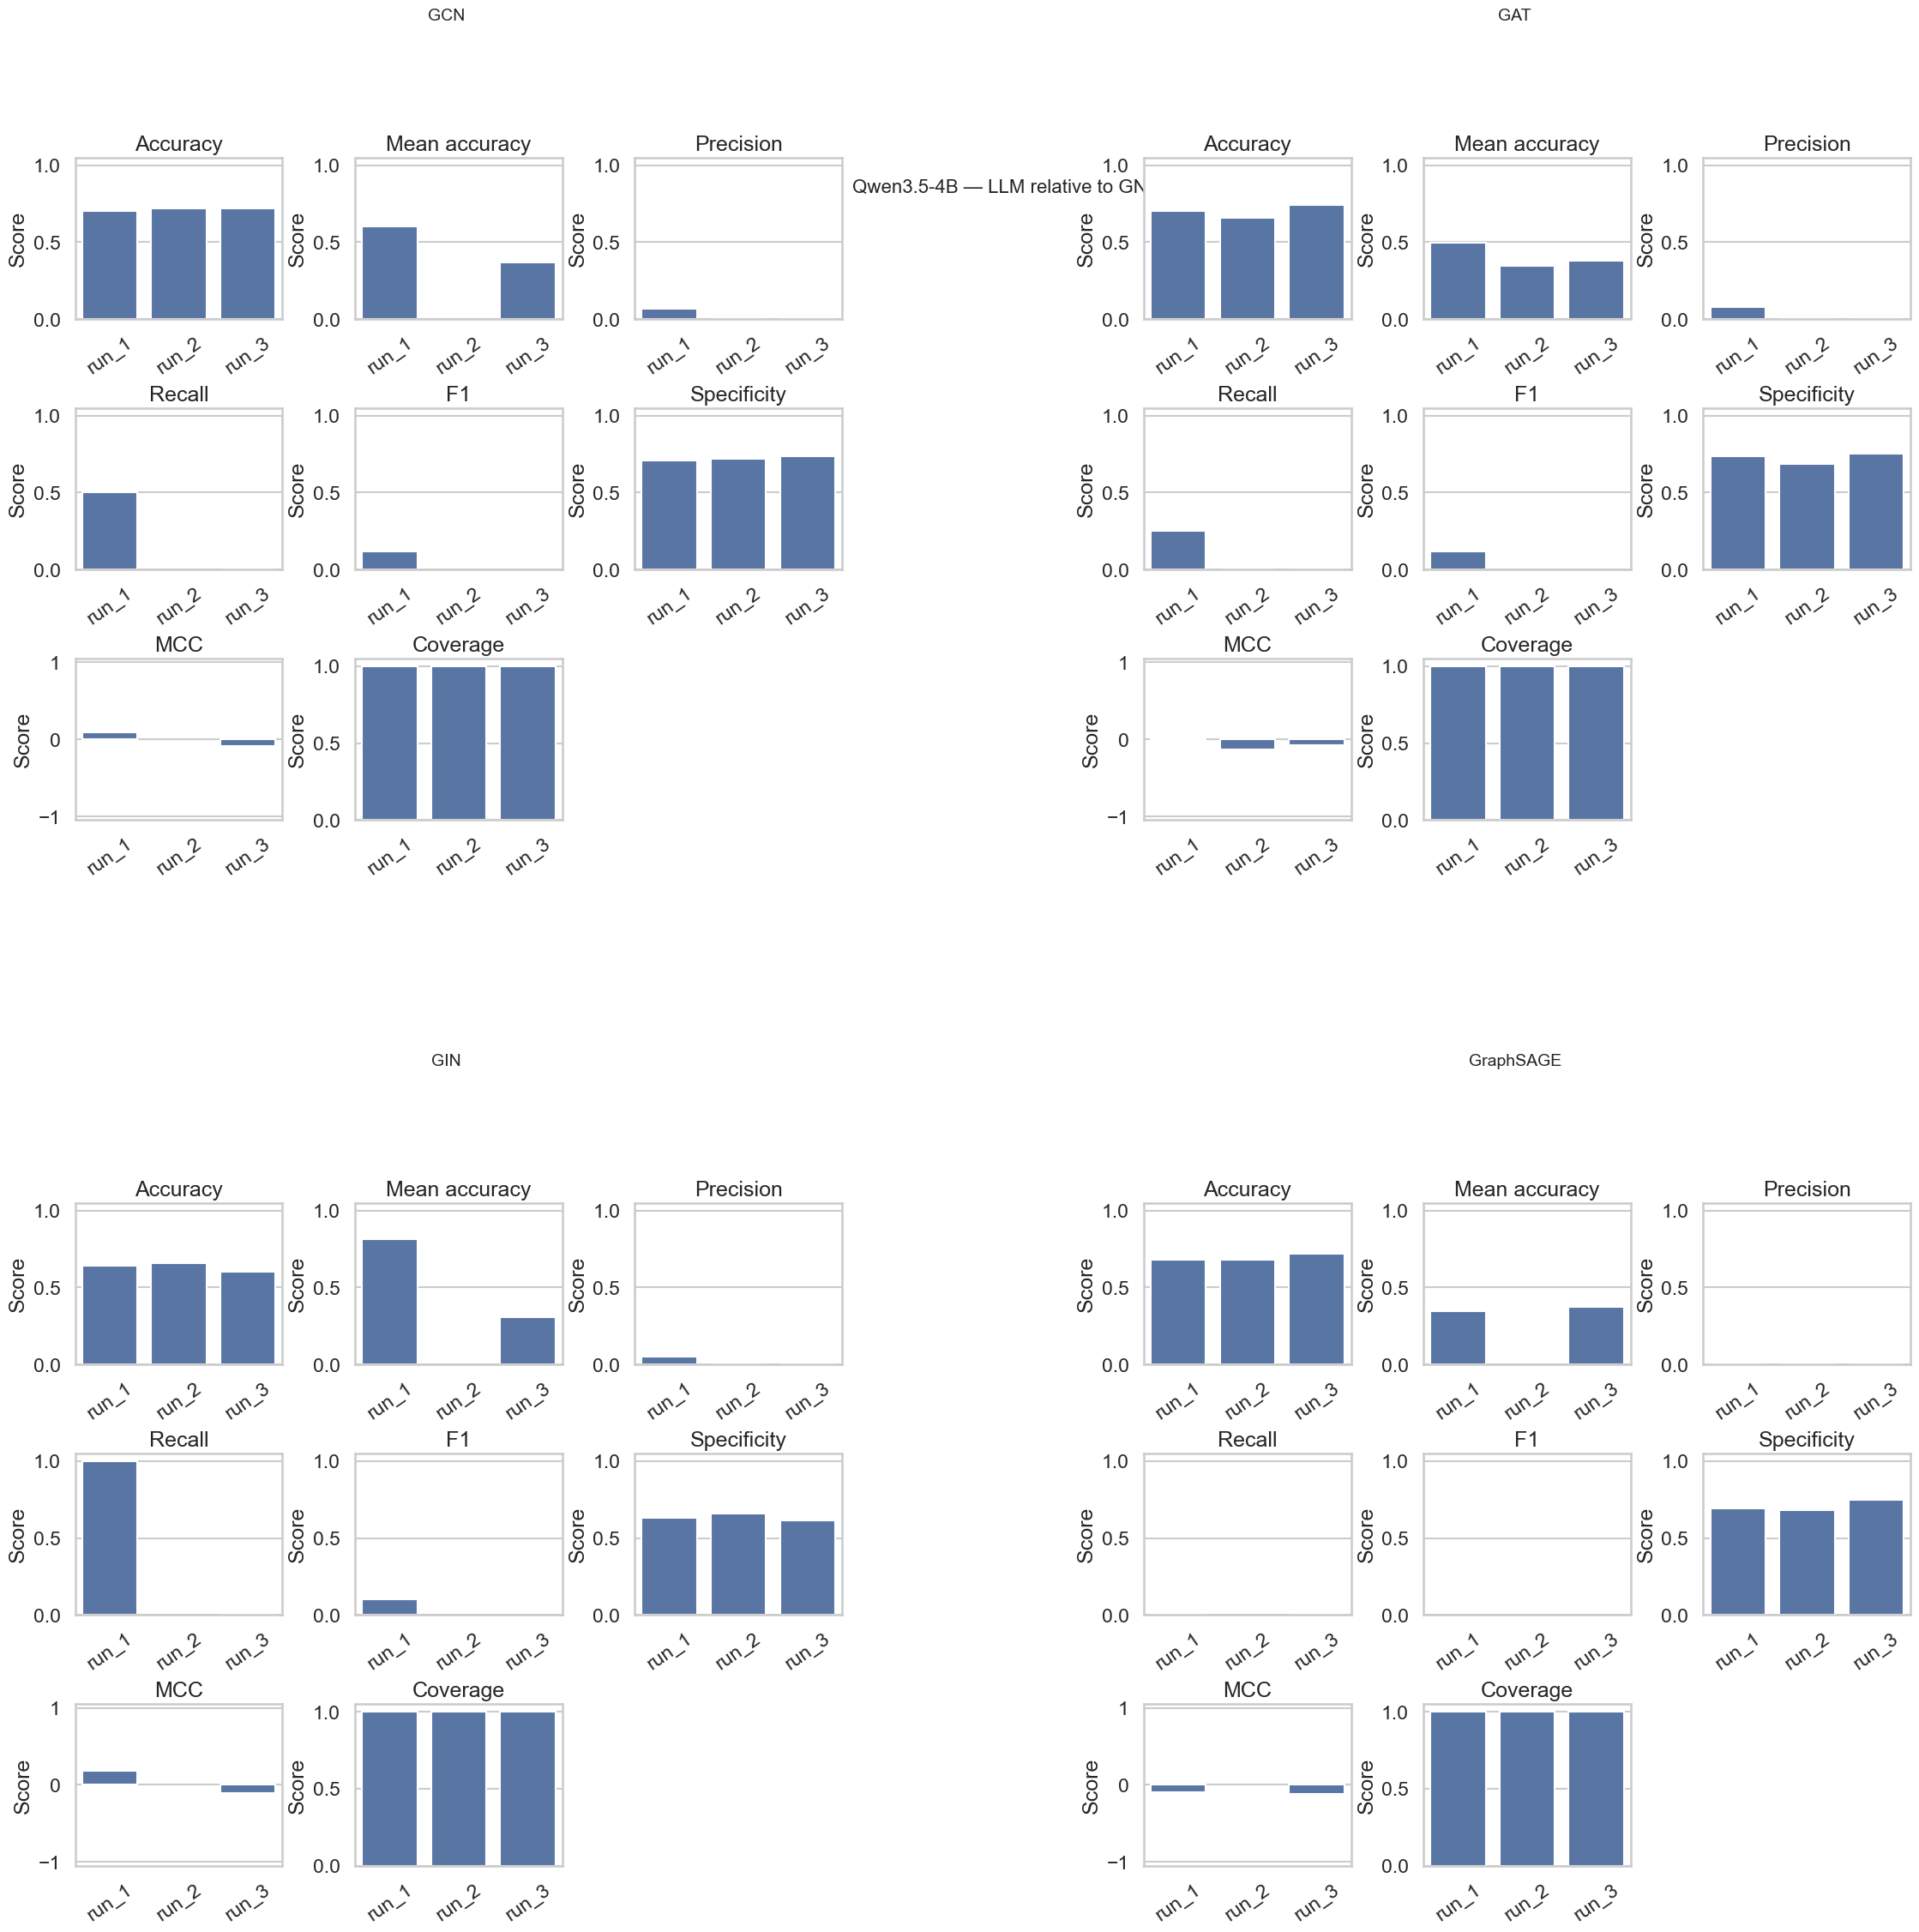

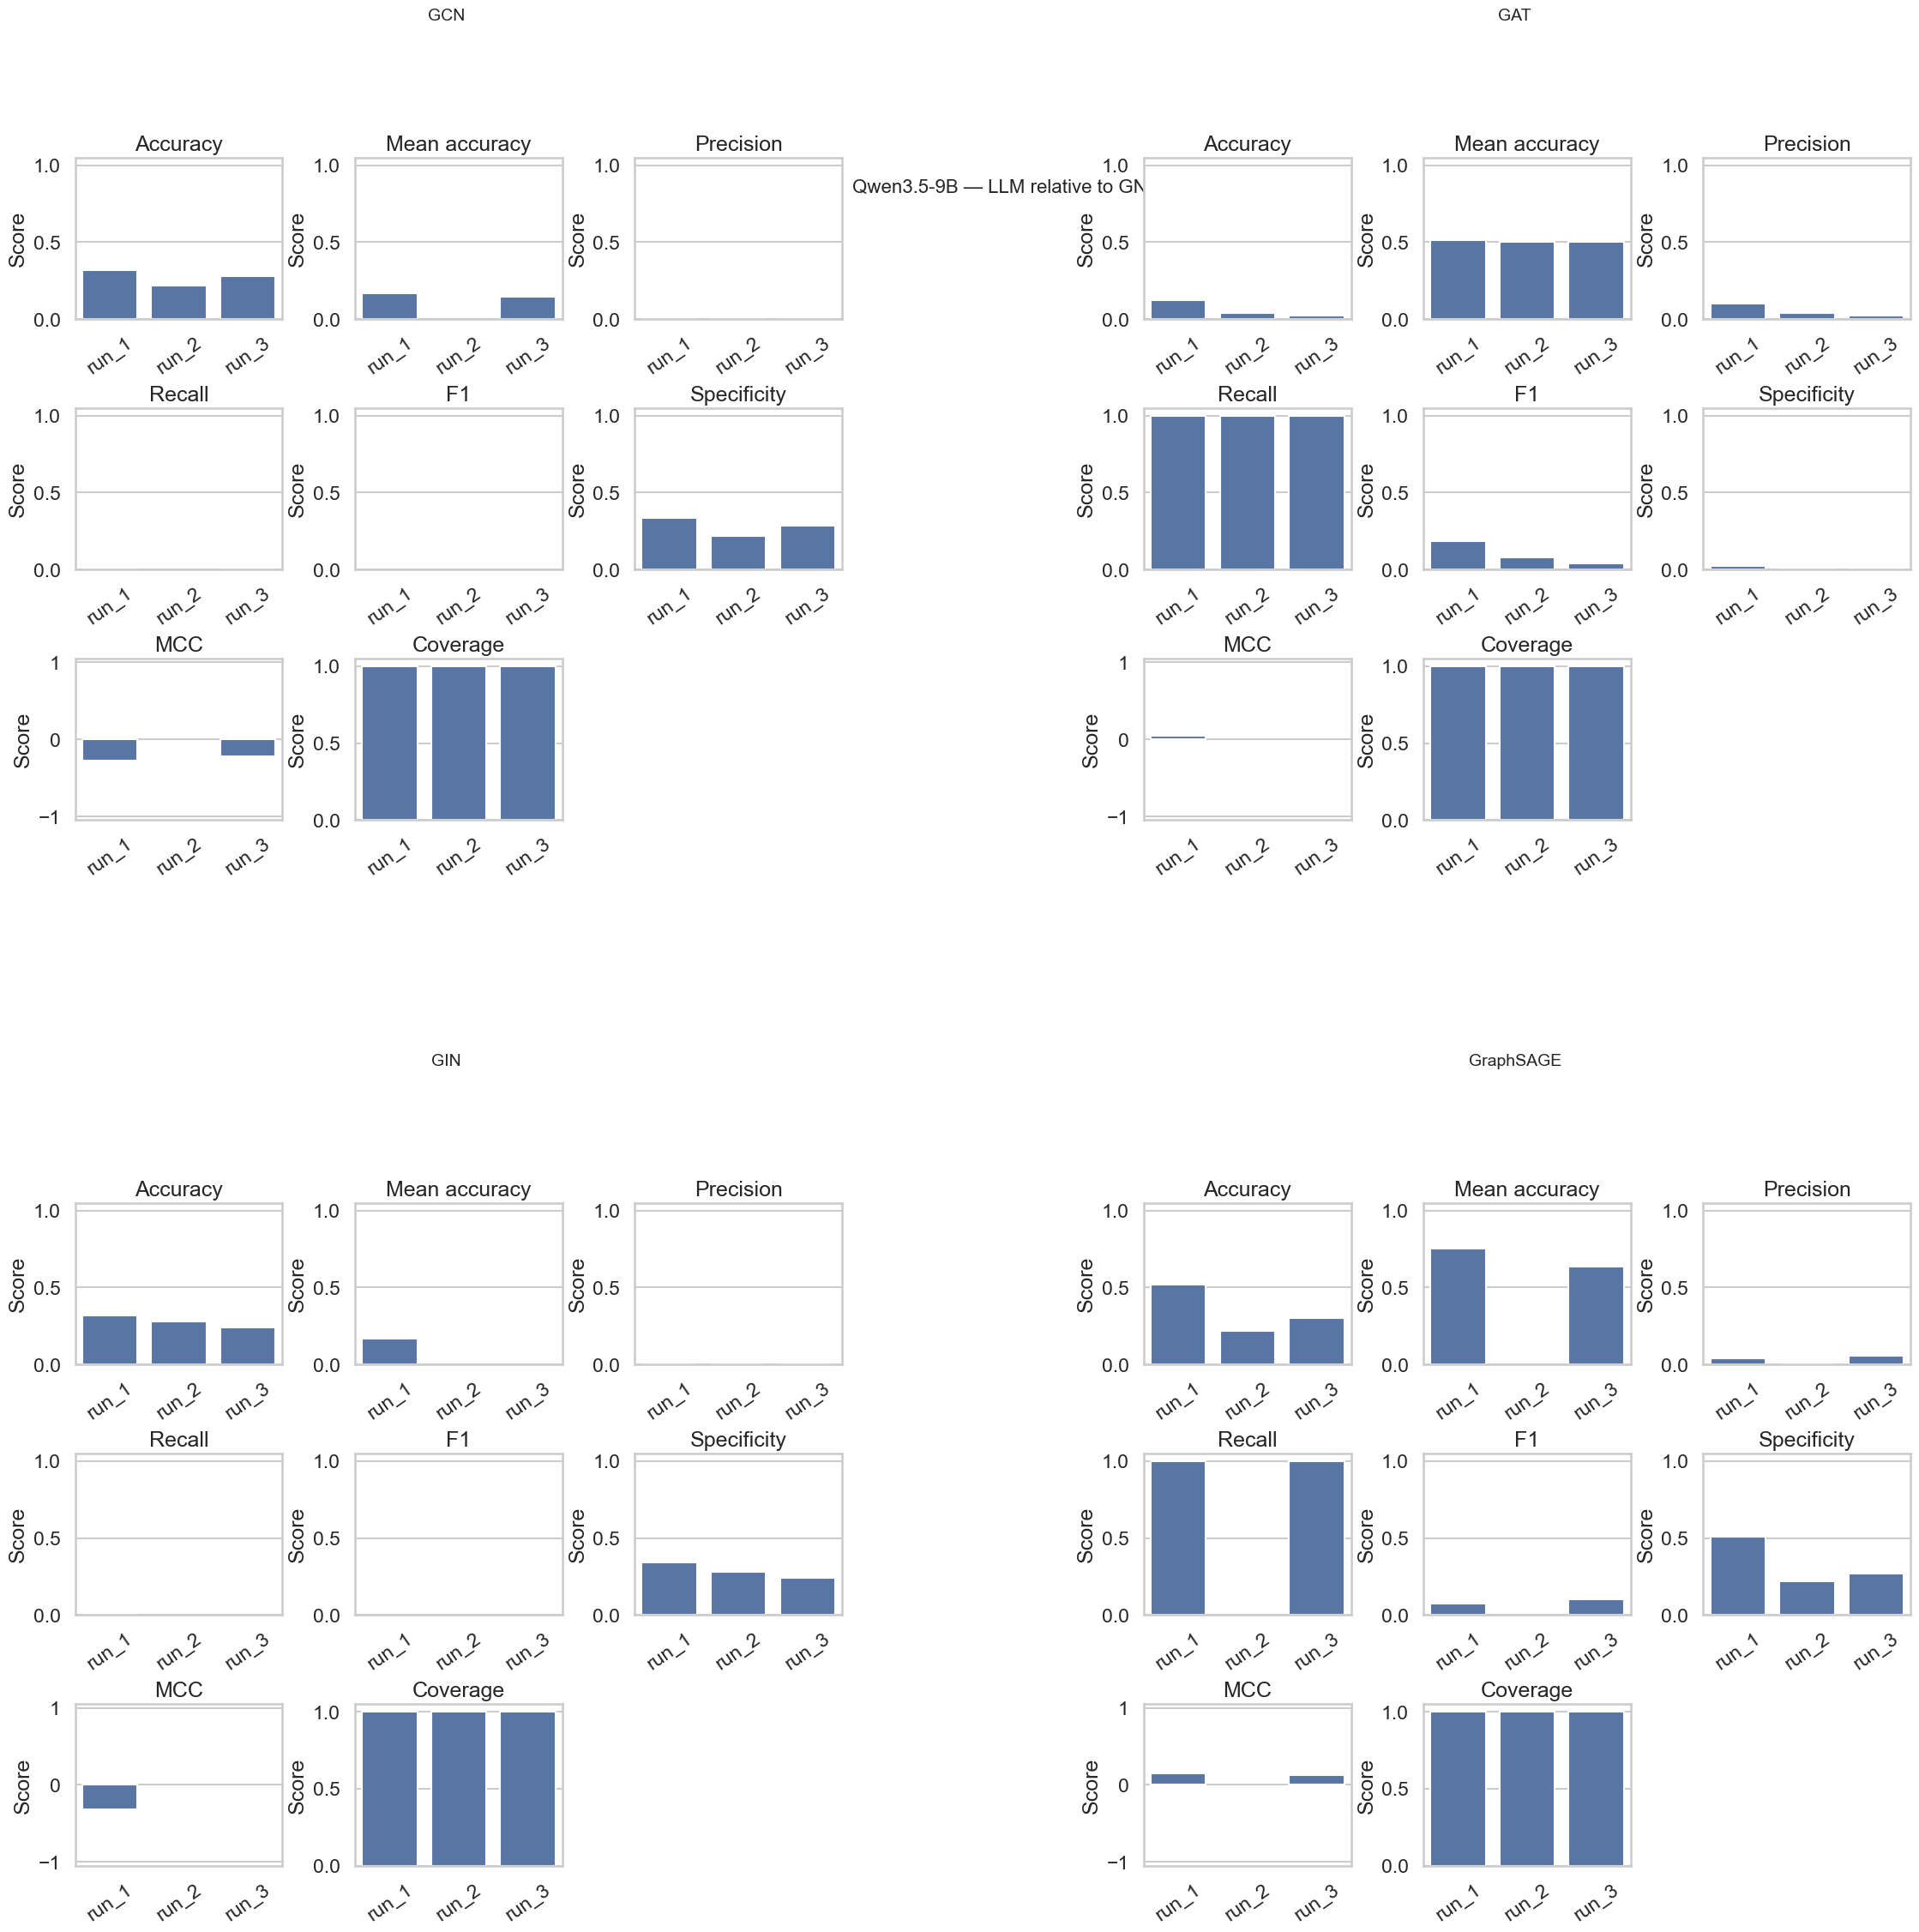

In [7]:
selected_runs = DEFAULT_SELECTED_RUNS
selected_models = DEFAULT_SELECTED_MODELS

results_df = load_selected_runs(SNELLIUS_ROOT, selected_runs=selected_runs, selected_models=selected_models)
if results_df.empty:
    raise FileNotFoundError(f"No results found under {SNELLIUS_ROOT}")

metrics_df = build_metrics_frame(results_df)

index_cols = ["run", "model_name", "comparison"]
if "gnn_model" in metrics_df.columns:
    index_cols = ["run", "model_name", "gnn_model", "comparison"]

summary_df = (
    metrics_df[metrics_df["metric"].isin(METRIC_ORDER)]
    .pivot_table(
        index=index_cols,
        columns="metric",
        values="value",
        aggfunc="first",
    )
    .reset_index()
)

gnn_count = results_df["gnn_model"].nunique() if "gnn_model" in results_df.columns else 0
print(
    f"Loaded {len(results_df)} rows from {results_df['run'].nunique()} run(s), "
    f"{results_df['model_name'].nunique()} LLM model(s), and {gnn_count} GNN model(s)."
)

sort_cols = ["comparison", "run", "model_name"]
if "gnn_model" in summary_df.columns:
    sort_cols = ["comparison", "gnn_model", "run", "model_name"]

display(summary_df.sort_values(sort_cols))

# Create one metrics figure per LLM model, per comparison (each figure is a 2x2 grid over GNN models)
save_metrics_dir = WORKSPACE_ROOT / "outputs" / "plots" / "metrics_by_model"
for comparison_name in COMPARISONS:
    plot_metrics_split_by_model(
        metrics_df,
        comparison_name,
        selected_runs=selected_runs,
        selected_models=selected_models,
        save_dir=save_metrics_dir,
    )

plt.show()


In [ ]:
def _confusion_matrix_from_counts(tp, tn, fp, fn):
    return np.array([[tn, fp],
                     [fn, tp]])

def plot_confusion_matrices(results_df, selected_runs=None, selected_models=None, save_dir=None, figsize_per=4):
    df = results_df.copy()
    if selected_runs is not None:
        df = df[df["run"].isin(selected_runs)]
    if selected_models is not None:
        df = df[df["model_name"].isin(selected_models)]

    if df.empty:
        print("No data to plot.")
        return

    # Overall matrix (LLM as preds vs GNN as truth)
    overall_tp, overall_tn, overall_fp, overall_fn, overall_valid = confusion_counts(
        df["gnn_pred"].tolist(), df["llm_pred_parsed"].tolist()
    )
    overall_mat = _confusion_matrix_from_counts(overall_tp, overall_tn, overall_fp, overall_fn)

    n_models = df["model_name"].nunique()
    n_cols = min(4, n_models + 1)
    n_rows = int(np.ceil((n_models + 1) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * figsize_per, n_rows * figsize_per))
    axes = np.array(axes).reshape(-1)

    # Plot overall first
    ax0 = axes[0]
    sns.heatmap(overall_mat, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax0)
    ax0.set_title("Overall (LLM preds vs GNN true)")
    ax0.set_xlabel("LLM prediction")
    ax0.set_ylabel("GNN true")
    ax0.set_xticklabels(["0", "1"])
    ax0.set_yticklabels(["0", "1"], rotation=0)

    # Per-model matrices
    for i, (model_name, group) in enumerate(df.groupby("model_name", sort=True, observed=False), start=1):
        tp, tn, fp, fn, valid = confusion_counts(group["gnn_pred"].tolist(), group["llm_pred_parsed"].tolist())
        mat = _confusion_matrix_from_counts(tp, tn, fp, fn)
        ax = axes[i]
        sns.heatmap(mat, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
        ax.set_title(f"{model_name}\n(valid={valid})")
        ax.set_xlabel("LLM prediction")
        ax.set_ylabel("GNN true")
        ax.set_xticklabels(["0", "1"])
        ax.set_yticklabels(["0", "1"], rotation=0)

    # Turn off any unused axes
    for j in range(n_models + 1, len(axes)):
        axes[j].set_axis_off()

    fig.tight_layout()
    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_dir / "confusion_matrices_overall_and_per_model.png", dpi=200, bbox_inches="tight")
    return fig

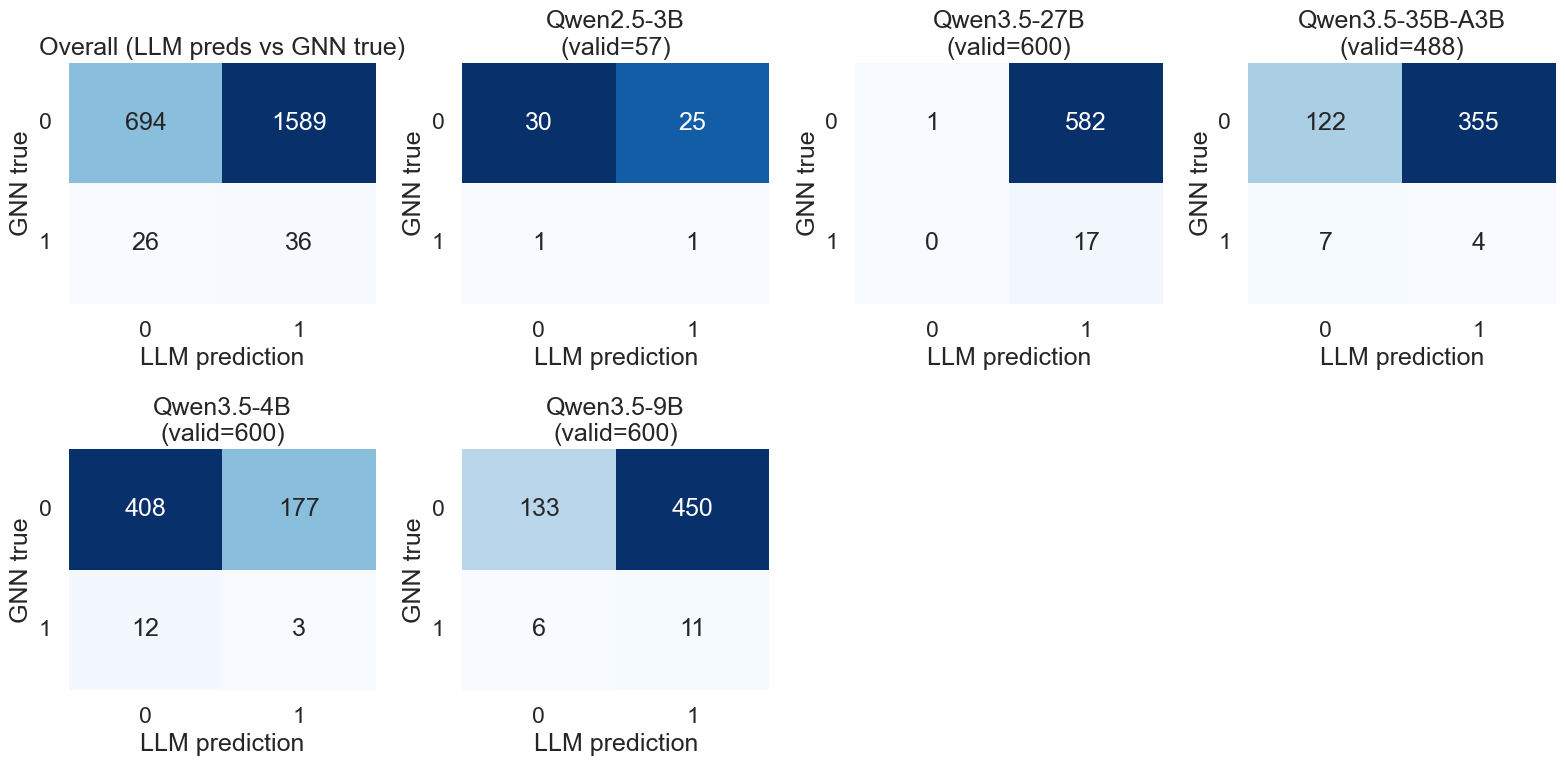

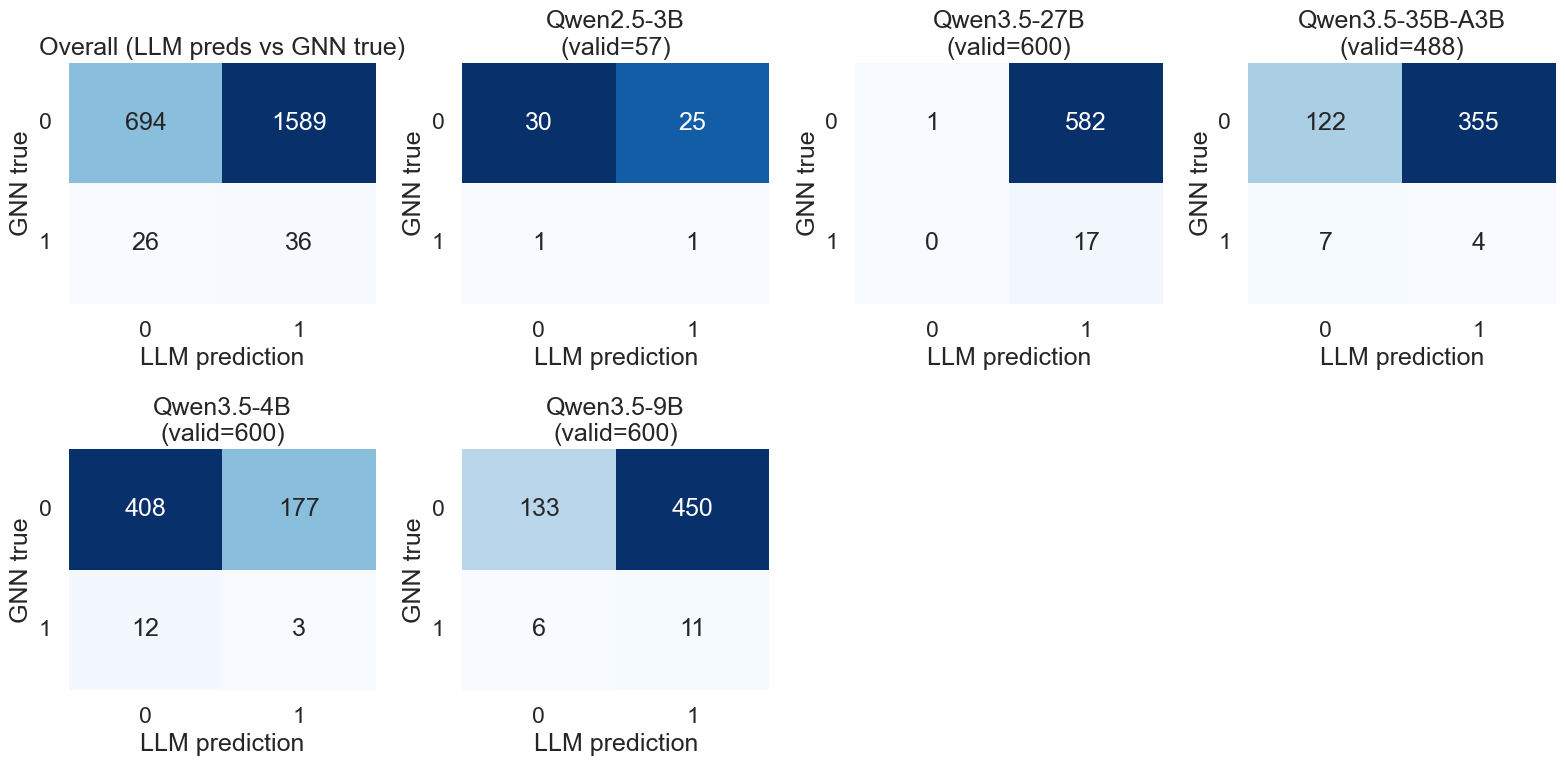

In [ ]:
out_dir = WORKSPACE_ROOT / "outputs" / "plots" / "confusion_matrices"
plot_confusion_matrices(results_df, selected_runs=selected_runs, selected_models=selected_models, save_dir=out_dir)